# Tech Challenge - Fase 1

## Desafio

Um grande hospital universitário busca implementar um sistema inteligente de suporte ao diagnóstico, capaz de ajudar médicos e equipes clínicas na análise inicial de exames e no processamento de dados médicos.

Com um volume crescente de pacientes e exames, como radiografias, tomografias, ressonâncias e prontuários digitalizados, o hospital precisa de soluções que acelerem a triagem e apoiem as decisões médicas, reduzindo erros e otimizando o tempo dos profissionais.

Nesta primeira fase, o desafio é criar a base do sistema de IA focado em machine learning, permitindo que resultados de exames sejam analisados automaticamente e destacando informações relevantes para o diagnóstico.

### Objetivo

Construir uma solução inicial com foco em IA para processamento de exames médicos e documentos clínicos, aplicando fundamentos essenciais de IA, Machine Learning e Visão Computacional.

### Patologia escolhida para o desafio: Acidente Vascular Cerebral (AVC)

* [Documentaçao do projeto](https://github.com/paulosobral/fiap-pos-tech-ia-para-devs/blob/01-welcome-to-ia-para-devs/07-tech-challenge/01-aulas-gravadas/01-welcome-to-ia-para-devs/07-tech-challenge/README.md "Tech Challenge - Fase 1 AVC")

* [Vídeo de apresentação do projeto](https://youtu.be/twPY-lL5yYM "Tech Challenge - Fase 1 AVC")

## Importando os Dados

In [2]:
import pandas as pd  # importa a biblioteca pandas
pd.set_option('display.max_columns', None)  # configura o pandas para mostrar todas as colunas ao exibir DataFrames

cycle_map = {

    "2005-2006": "_D",
    "2007-2008": "_E",
    "2009-2010": "_F",
    "2011-2012": "_G",
    "2013-2014": "_H",
    "2015-2016": "_I",
    "2017-2018": "_J"
}

modules = {  # dicionário que mapeia nomes lógicos para templates de arquivos XPT
    "demo": "DEMO{}.XPT",  # arquivo DEMO (dados demográficos): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.htm (ajustado para usar a letra do ciclo)
    "bpx": "BPX{}.XPT",     # arquivo BPX (medidas de pressão arterial): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.htm
    "bpq": "BPQ{}.XPT", # arquivo BPQ (pressão arterial e colesterol): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.htm
    "ocq": "OCQ{}.XPT",     # arquivo OCQ (questionário de ocupação): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/OCQ_J.htm
    "ghb": "GHB{}.XPT",     # arquivo GHB (hemoglobina glicada): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.htm
    "bmx": "BMX{}.XPT",     # arquivo BMX (medidas corporais): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm
    "smq": "SMQ{}.XPT",     # arquivo SMQ (questionário de tabagismo): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SMQ_J.htm
    "mcq": "MCQ{}.XPT"     # arquivo de questionário médico (histórico de doenças): https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/MCQ_J.htm
}

dfs = {name: [] for name in modules}  # dicionário de listas para armazenar os DataFrames de cada módulo por ciclo

cycles = list(cycle_map.keys())  # lista de ciclos (ex.: ["2011-2012", "2017-2018"])

for cycle in cycles:
    letter = cycle_map[cycle]  # obtém a letra do ciclo (ex.: "G" para "2011-2012")
    year = cycle.split('-')[0]  # obtém o ano inicial do ciclo (ex.: "2011" para "2011-2012")
    base_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/" + year + "/DataFiles/"  # URL base para os arquivos NHANES, usando o ano inicial
    for name, file_template in modules.items():  # itera sobre (nome, template de arquivo) do dicionário modules
        file = file_template.format(letter)  # formata o template com a letra do ciclo (ex.: "DEMO_G.XPT")
        print(f"Carregando {file} para o ciclo {cycle}...")
        dfs[name].append(pd.read_sas(base_url + file))  # lê o arquivo XPT remoto e adiciona à lista de dfs[name]

# concatena os DataFrames de cada módulo de todos os ciclos
demo_df = pd.concat(dfs["demo"], ignore_index=True)
bpx_df = pd.concat(dfs["bpx"], ignore_index=True)
bpq_df = pd.concat(dfs["bpq"], ignore_index=True)
ocq_df = pd.concat(dfs["ocq"], ignore_index=True)
ghb_df = pd.concat(dfs["ghb"], ignore_index=True)
bmx_df = pd.concat(dfs["bmx"], ignore_index=True)
smq_df = pd.concat(dfs["smq"], ignore_index=True)
mcq_df = pd.concat(dfs["mcq"], ignore_index=True)

# inicia com o DataFrame 'demo' concatenado e faz merges left sucessivos com os outros DataFrames concatenados usando 'SEQN' como chave
df = demo_df \
    .merge(bpx_df, on="SEQN", how="left") \
    .merge(bpq_df, on="SEQN", how="left") \
    .merge(ocq_df, on="SEQN", how="left") \
    .merge(ghb_df, on="SEQN", how="left") \
    .merge(bmx_df, on="SEQN", how="left") \
    .merge(smq_df, on="SEQN", how="left") \
    .merge(mcq_df, on="SEQN", how="left")

df.head()  # exibe a forma (número de linhas e colunas) do DataFrame final combinado


Carregando DEMO_D.XPT para o ciclo 2005-2006...
Carregando BPX_D.XPT para o ciclo 2005-2006...
Carregando BPQ_D.XPT para o ciclo 2005-2006...
Carregando OCQ_D.XPT para o ciclo 2005-2006...
Carregando GHB_D.XPT para o ciclo 2005-2006...
Carregando BMX_D.XPT para o ciclo 2005-2006...
Carregando SMQ_D.XPT para o ciclo 2005-2006...
Carregando MCQ_D.XPT para o ciclo 2005-2006...
Carregando DEMO_E.XPT para o ciclo 2007-2008...
Carregando BPX_E.XPT para o ciclo 2007-2008...
Carregando BPQ_E.XPT para o ciclo 2007-2008...
Carregando OCQ_E.XPT para o ciclo 2007-2008...
Carregando GHB_E.XPT para o ciclo 2007-2008...
Carregando BMX_E.XPT para o ciclo 2007-2008...
Carregando SMQ_E.XPT para o ciclo 2007-2008...
Carregando MCQ_E.XPT para o ciclo 2007-2008...
Carregando DEMO_F.XPT para o ciclo 2009-2010...
Carregando BPX_F.XPT para o ciclo 2009-2010...
Carregando BPQ_F.XPT para o ciclo 2009-2010...
Carregando OCQ_F.XPT para o ciclo 2009-2010...
Carregando GHB_F.XPT para o ciclo 2009-2010...
Carregando

,SEQN,SDDSRVYR,RIDSTATR,RIDEXMON,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDAGEEX,RIDRETH1,DMQMILIT,DMDBORN,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDSCHOL,DMDMARTL,DMDHHSIZ,DMDFMSIZ,INDHHINC,INDFMINC,INDFMPIR,RIDEXPRG,DMDHRGND,DMDHRAGE,DMDHRBRN,DMDHREDU,DMDHRMAR,DMDHSEDU,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANG,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,DMDBORN2,INDHHIN2,INDFMIN2,DMDHRBR2,RIDRETH3,RIDEXAGY,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,AIALANGA,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRBR4,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,PEASCST1,PEASCTM1,PEASCCT1,BPXCHR,BPQ150A,BPQ150B,BPQ150C,BPQ150D,BPAARM,BPACSZ,BPXPLS,BPXDB,BPXPULS,BPXPTY,BPXML1,BPXSY1,BPXDI1,BPAEN1,BPXSY2,BPXDI2,BPAEN2,BPXSY3,BPXDI3,BPAEN3,BPXSY4,BPXDI4,BPAEN4,BPQ020,BPQ030,BPQ040A,BPQ050A,BPQ060,BPQ070,BPQ080,BPQ090A,BPQ090B,BPQ090C,BPQ090D,BPQ100A,BPQ100B,BPQ100C,BPQ100D,BPD035,BPQ052,BPQ057,BPQ056,BPD058,BPQ059,OCD150,OCQ180,OCQ210,OCD231,OCD241,OCQ260,OCQ265,OCD270,OCQ290G,OCQ290Q,OCQ380,OCD390G,OCD392,OCD395,OCD391,OCQ510,OCQ520,OCQ530,OCQ540,OCQ550,OCQ560,OCQ570,OCQ580,OCQ275,OCQ600,OCQ610,OCQ630,OCQ640,OCQ660,OCQ670,LBXGH,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMXLEG,BMILEG,BMXCALF,BMICALF,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXTHICR,BMITHICR,BMXTRI,BMITRI,BMXSUB,BMISUB,BMDBMIC,BMXSAD1,BMXSAD2,BMXSAD3,BMXSAD4,BMDAVSAD,BMDSADCM,BMXHIP,BMIHIP,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD055,SMD057,SMD070,SMD075,SMQ077,SMD641,SMD650,SMD093,SMDUPCA,SMD100BR,SMD100FL,SMD100MN,SMD100LN,SMD100TR,SMD100NI,SMD100CO,SMQ620,SMD630,SMQ660,SMQ664M,SMQ664C,SMQ664W,SMQ664B,SMQ664O,SMQ666M,SMQ666C,SMQ666K,SMQ666W,SMQ666B,SMQ666S,SMQ666O,SMQ670,SMAQUEX2,SMQ621,SMQ078,SMQ661,SMQ665A,SMQ665B,SMQ665C,SMQ665D,SMQ848,SMQ852Q,SMQ852U,SMQ925,SMQ930,SMQ935,SMQ080,SMQ890,SMQ895,SMQ900,SMQ905,SMQ910,SMQ915,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,MCQ053,MCQ080,MCQ092,MCD093,MCQ140,MCQ149,MCQ150G,MCQ150Q,MCQ160A,MCQ160B,MCQ160C,MCQ160D,MCQ160E,MCQ160F,MCQ160G,MCQ160K,MCQ160L,MCQ160M,MCQ170K,MCQ170L,MCQ170M,MCQ180A,MCQ180B,MCQ180C,MCQ180D,MCQ180E,MCQ180F,MCQ180G,MCQ180K,MCQ180L,MCQ180M,MCQ190,MCQ220,MCQ230A,MCQ230B,MCQ230C,MCQ230D,MCQ240A,MCQ240B,MCQ240C,MCQ240D,MCQ240E,MCQ240F,MCQ240G,MCQ240H,MCQ240I,MCQ240J,MCQ240K,MCQ240L,MCQ240M,MCQ240N,MCQ240O,MCQ240P,MCQ240Q,MCQ240R,MCQ240S,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ240AA,MCQ240BB,MCQ240CC,MCQ240DD,MCQ240DK,MCQ245A,MCQ245B,MCQ265,MCQ268A,MCQ268B,MCQ268C,MCQ268D,MCQ300A,MCQ300B,MCQ300C,MCQ310,MCQ320,MCD330,MCQ340,MCQ350,MCQ051,MCQ160N,MCQ180N,MCQ070,MCQ082,MCQ086,MCQ191,MCQ075,MCQ084,MCQ195,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,AGQ030,MCQ151,MCQ160O,MCQ203,MCQ206,OSQ230,RHD018,MCD180A,MCD180N,MCD180B,MCD180C,MCD180D,MCD180E,MCD180F,MCD180M,MCD180G,MCD180K,MCD180L,MCQ500,MCQ510A,MCQ510B,MCQ510C,MCQ510D,MCQ510E,MCQ510F,MCQ520,MCQ530,MCQ540,MCQ550,MCQ560,MCQ570,MCD240A,MCD240B,MCD240C,MCQ366A,MCQ366B,MCQ366C,MCQ366D,MCQ371A,MCQ371B,MCQ371C,MCQ371D
0,31127.0,4.0,2.0,2.0,1.0,5.397605e-79,11.0,12.0,3.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,4.0,0.75,NaN,2.0,21.0,1.0,3.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,6434.950248,6571.396373,2.0,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,41.0,NaN,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,10.2,NaN,73.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,NaN,15.5,NaN,NaN,NaN,NaN,NaN,12.8,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [3]:

df.shape

(70190, 383)

## Preparando os Dados

In [4]:
# manter somente as colunas solicitadas (se existirem) e avisar se alguma estiver ausente
cols_to_keep = [
    "SEQN", # Respondent sequence number
    "RIAGENDR", # Gender (DEMO): 1 - Male, 2 - Female
    "RIDAGEYR", # Age in years at screening (DEMO): 0 YEARS - 150 YEARS
    "BPQ020", # Ever told you had high blood pressure (BPQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160B",  # Ever told had congestive heart failure (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "DMDMARTL", # Marital status (DEMO): 1 - Married, 2 - Widowed, 3 - Divorced, 4 - Separated, 5 - Never married, 6 - Living with partner
    "OCQ260", # Description of job/work situation (OCQ): 1 - An employee of a private company, business, or individual for wages, salary, or commission., 2 - A federal government employee, 3 - A state government employee, 4 - A local government employee, 5 - Self-employed in own business, Working without pay in family business or farm, 6 - Refused, 77 - Don't know, 99 - Refused
    "BPXSY1", # Systolic blood pressure (BPX): 72 to 228 mm Hg
    "LBXGH", # Glycohemoglobin (GHB)
    "BMXBMI", # Body Mass Index (BMX)
    "SMQ020", # Ever smoked a cigar even 1 time? (SMQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
    "MCQ160F" # TARGET -> Ever told you had a stroke (MCQ): 1 - Yes, 2 - No, 7 - Refused, 9 - Don't know
]

# verifica colunas ausentes
missing = [c for c in cols_to_keep if c not in df.columns]
if missing:
    print("Aviso: colunas ausentes e que não foram selecionadas:", missing)

# filtra o DataFrame para manter somente as colunas desejadas que existem
df = df[[c for c in cols_to_keep if c in df.columns]].copy()

# renomeia as colunas usando sufixos descritivos
suffix_descriptions = {
    "SEQN": "id", # Respondent sequence number
    "RIAGENDR": "gender", # Gender
    "RIDAGEYR": "age", # Age in years
    "BPQ020": "high_bp", # High blood pressure
    "MCQ160B": "chf", # Congestive heart failure
    "DMDMARTL": "marital", # Marital status
    "OCQ260": "occupation", # Occupation
    "BPXSY1": "sbp", # Systolic blood pressure
    "LBXGH": "hba1c", # Glycohemoglobin
    "BMXBMI": "bmi", # Body Mass Index
    "SMQ020": "smoking", # Smoking
    "MCQ160F": "stroke" # Ever told you had a stroke
}

# renomeia as colunas do DataFrame
rename_map = {c: f"{c}_{suffix_descriptions[c]}" for c in df.columns if c in suffix_descriptions}
df = df.rename(columns=rename_map)

print("Colunas renomeadas:", list(rename_map.values()))

df.shape

Colunas renomeadas: ['SEQN_id', 'RIAGENDR_gender', 'RIDAGEYR_age', 'BPQ020_high_bp', 'MCQ160B_chf', 'DMDMARTL_marital', 'OCQ260_occupation', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi', 'SMQ020_smoking', 'MCQ160F_stroke']


(70190, 12)

In [5]:
df.head(5)

,SEQN_id,RIAGENDR_gender,RIDAGEYR_age,BPQ020_high_bp,MCQ160B_chf,DMDMARTL_marital,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,SMQ020_smoking,MCQ160F_stroke
0,31127.0,1.0,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,31128.0,2.0,1.100000e+01,NaN,NaN,NaN,NaN,100.0,NaN,17.45,NaN,NaN
2,31129.0,1.0,1.500000e+01,NaN,NaN,5.0,NaN,104.0,5.2,26.53,NaN,NaN
3,31130.0,2.0,8.500000e+01,2.0,2.0,2.0,NaN,NaN,NaN,NaN,2.0,2.0
4,31131.0,2.0,4.400000e+01,1.0,1.0,1.0,1.0,144.0,6.0,30.90,2.0,2.0


In [6]:
# verificar as 20 colunas com mais valores ausentes
df.isnull().sum().sort_values(ascending=False).head(20)

OCQ260_occupation    46547
MCQ160B_chf          30442
MCQ160F_stroke       30442
SMQ020_smoking       29538
DMDMARTL_marital     28722
BPQ020_high_bp       25490
LBXGH_hba1c          25181
BPXSY1_sbp           21471
BMXBMI_bmi            8550
RIDAGEYR_age             0
SEQN_id                  0
RIAGENDR_gender          0
dtype: int64

In [7]:
# calcular o percentual de valores ausentes por coluna
total = len(df)

# exibir as 20 colunas com maior percentual de valores ausentes
(df.isnull().sum() / total * 100).sort_values(ascending=False).head(20)

OCQ260_occupation    66.315714
MCQ160B_chf          43.370851
MCQ160F_stroke       43.370851
SMQ020_smoking       42.082918
DMDMARTL_marital     40.920359
BPQ020_high_bp       36.315714
LBXGH_hba1c          35.875481
BPXSY1_sbp           30.589828
BMXBMI_bmi           12.181222
RIDAGEYR_age          0.000000
SEQN_id               0.000000
RIAGENDR_gender       0.000000
dtype: float64

<Axes: >

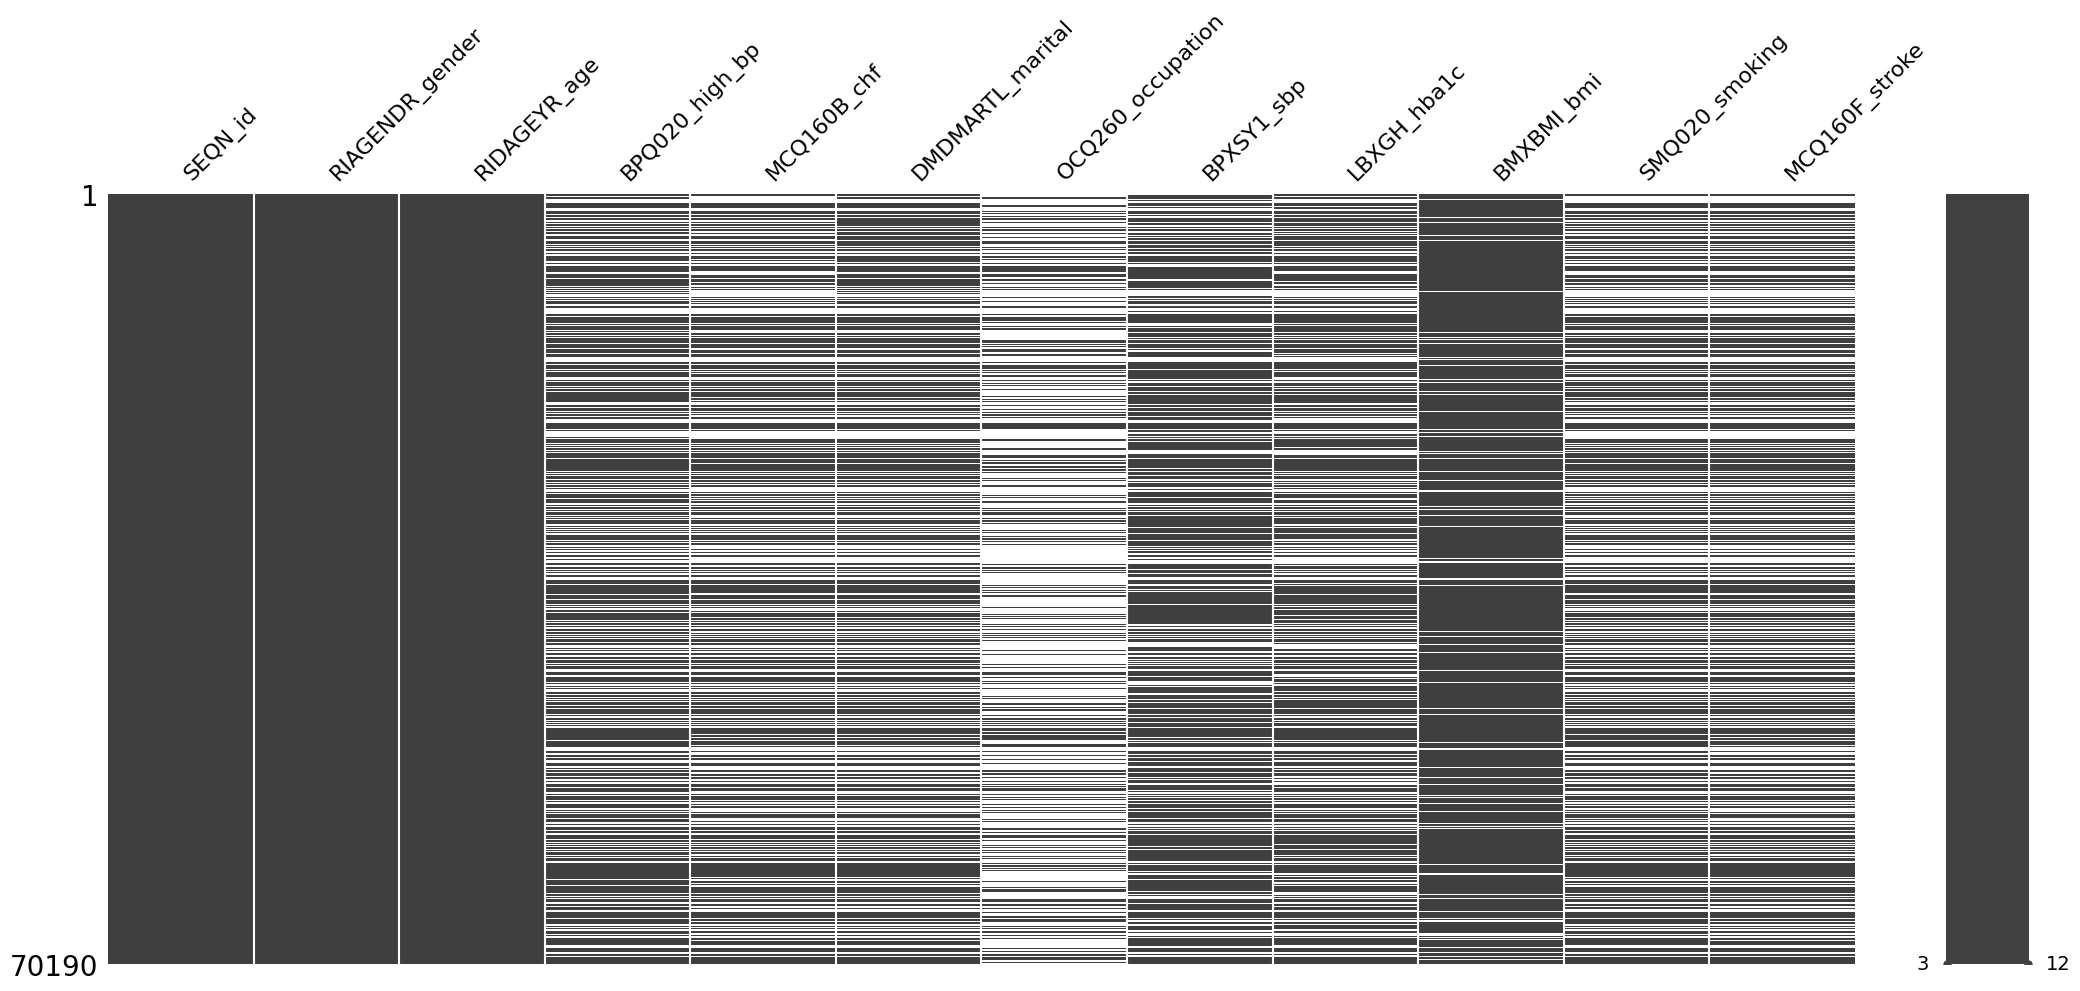

In [8]:
import missingno as msno # importa a biblioteca missingno para visualização de dados ausentes

# visualizar os valores ausentes no DataFrame
msno.matrix(df)

<Axes: >

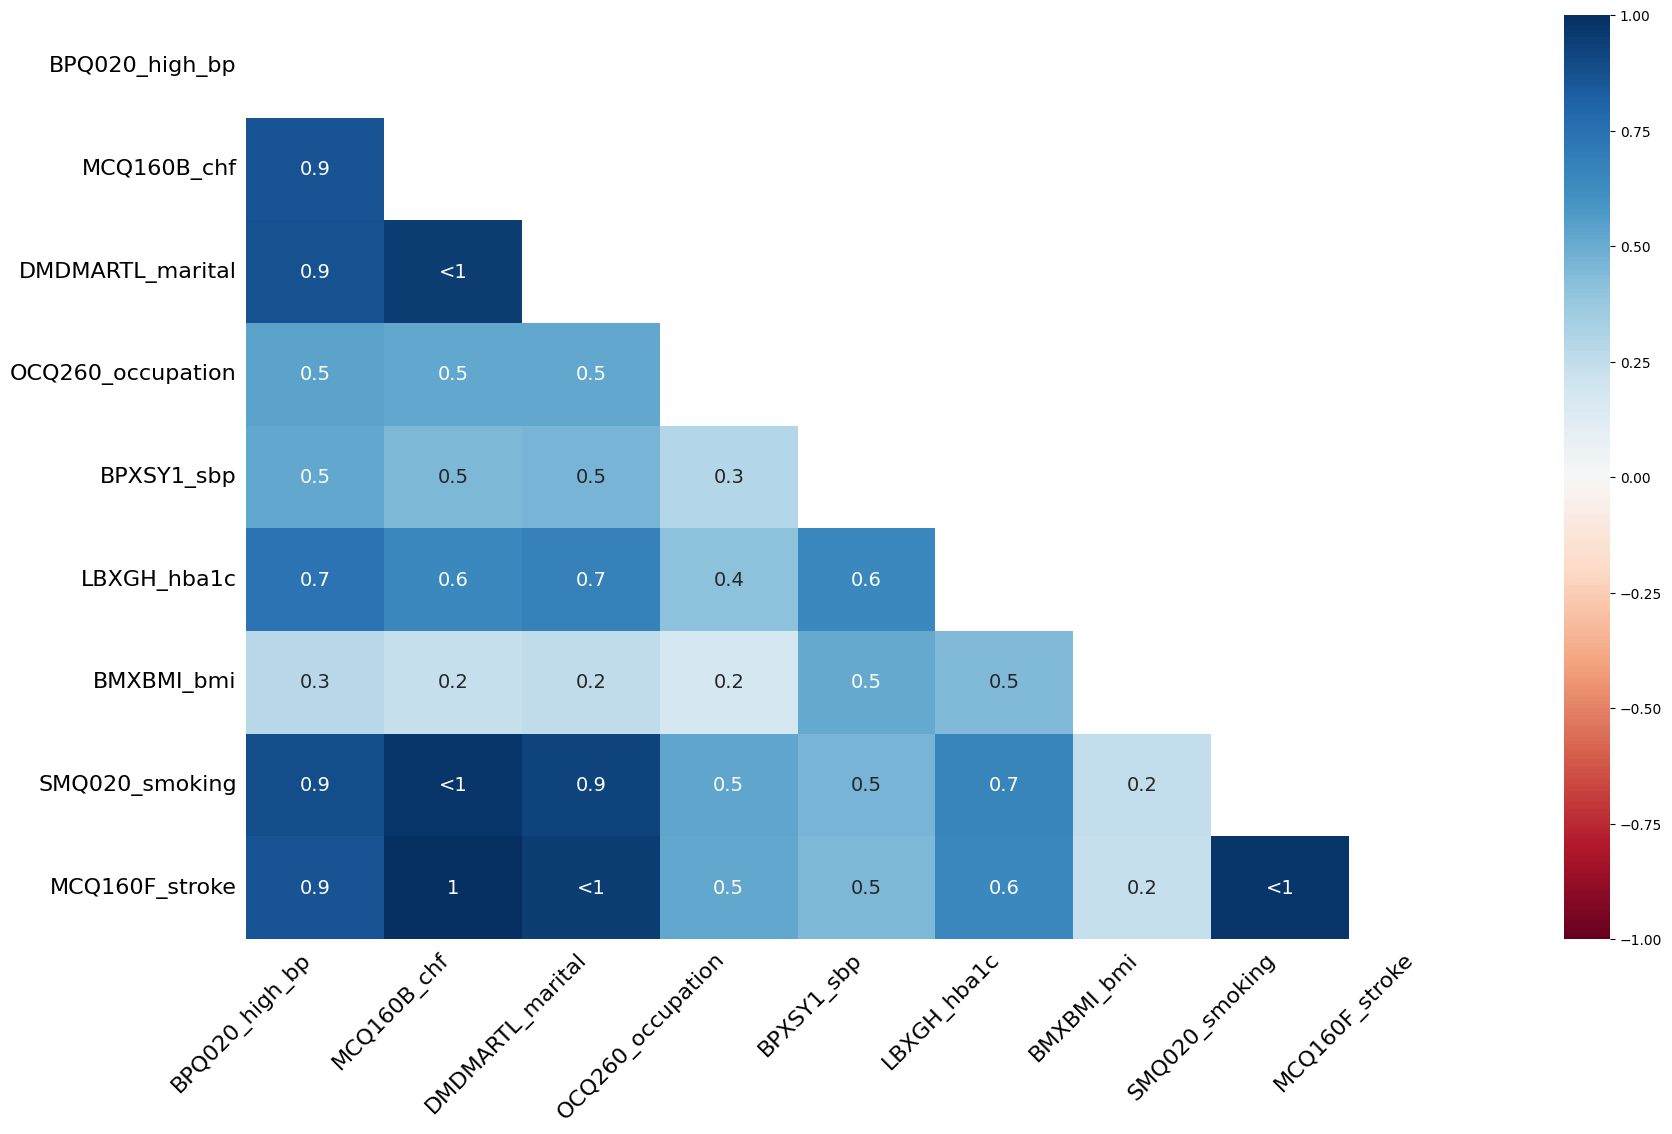

In [9]:
# visualizar o mapa de calor dos valores ausentes
msno.heatmap(df)

In [10]:
# exibir a forma inicial do DataFrame
print("Initial shape:", df.shape)

# Exibir missing por coluna
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing % per column:\n", missing_pct)

# Remover todas as linhas que possuem pelo menos um valor nulo
print('Shape antes do dropna:', df.shape)

# converter a coluna 'OCQ260_occupation' para numérica, tratando erros e preenchendo NaNs com 0, pensando em pessoas desempregadas;
df['OCQ260_occupation'] = pd.to_numeric(df['OCQ260_occupation'], errors='coerce').fillna(0)

# remover linhas com valores nulos
df = df.dropna()

print('Shape após remover todas as linhas com valores nulos:', df.shape)

# Verificar valores ambíguos nas variáveis categóricas e no alvo (códigos 7 e 9)
cat_cols = ['BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking', 'MCQ160F_stroke']

# exibir contagens de valores para as colunas categóricas
rows_after = df.shape[0]

# exibir contagens de valores para as colunas categóricas
for c in cat_cols:
    if c in df.columns:
        print(c, "contagens de valor:")
        print(df[c].value_counts(dropna=False))

# Remover códigos ambíguos (7,9) das colunas categóricas e do alvo (se existirem)
amb_cols = [c for c in cat_cols if c in df.columns]
rows_before = df.shape[0]
for c in amb_cols:
    df = df[~df[c].isin([7,9,77,99,77.0,99.0])]
rows_after = df.shape[0]
print(f"Linhas removidas devido a códigos ambíguos. (7/9/77/99): {rows_before - rows_after}")

df.shape

Initial shape: (70190, 12)
Missing % per column:
 OCQ260_occupation    66.315714
MCQ160B_chf          43.370851
MCQ160F_stroke       43.370851
SMQ020_smoking       42.082918
DMDMARTL_marital     40.920359
BPQ020_high_bp       36.315714
LBXGH_hba1c          35.875481
BPXSY1_sbp           30.589828
BMXBMI_bmi           12.181222
RIDAGEYR_age          0.000000
SEQN_id               0.000000
RIAGENDR_gender       0.000000
dtype: float64
Shape antes do dropna: (70190, 12)
Shape após remover todas as linhas com valores nulos: (32854, 12)
BPQ020_high_bp contagens de valor:
BPQ020_high_bp
2.0    21252
1.0    11552
9.0       50
Name: count, dtype: int64
MCQ160B_chf contagens de valor:
MCQ160B_chf
2.0    31737
1.0     1035
9.0       82
Name: count, dtype: int64
SMQ020_smoking contagens de valor:
SMQ020_smoking
2.0    18121
1.0    14714
9.0       16
7.0        3
Name: count, dtype: int64
MCQ160F_stroke contagens de valor:
MCQ160F_stroke
2.0    31597
1.0     1215
9.0       42
Name: count, dtype: i

(32669, 12)

In [11]:
df.head()

,SEQN_id,RIAGENDR_gender,RIDAGEYR_age,BPQ020_high_bp,MCQ160B_chf,DMDMARTL_marital,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,SMQ020_smoking,MCQ160F_stroke
4,31131.0,2.0,44.0,1.0,1.0,1.0,1.0,144.0,6.0,30.90,2.0,2.0
5,31132.0,1.0,70.0,1.0,2.0,1.0,1.0,138.0,7.1,24.74,2.0,2.0
7,31134.0,1.0,73.0,1.0,2.0,1.0,0.0,130.0,5.9,30.63,2.0,2.0
17,31144.0,1.0,21.0,2.0,2.0,5.0,2.0,116.0,4.8,25.03,2.0,2.0
22,31149.0,2.0,85.0,1.0,2.0,2.0,0.0,110.0,5.6,21.63,2.0,2.0


In [12]:
# Verificar o DataFrame final
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32669 entries, 4 to 70189
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SEQN_id            32669 non-null  float64
 1   RIAGENDR_gender    32669 non-null  float64
 2   RIDAGEYR_age       32669 non-null  float64
 3   BPQ020_high_bp     32669 non-null  float64
 4   MCQ160B_chf        32669 non-null  float64
 5   DMDMARTL_marital   32669 non-null  float64
 6   OCQ260_occupation  32669 non-null  float64
 7   BPXSY1_sbp         32669 non-null  float64
 8   LBXGH_hba1c        32669 non-null  float64
 9   BMXBMI_bmi         32669 non-null  float64
 10  SMQ020_smoking     32669 non-null  float64
 11  MCQ160F_stroke     32669 non-null  float64
dtypes: float64(12)
memory usage: 3.2 MB


<Axes: >

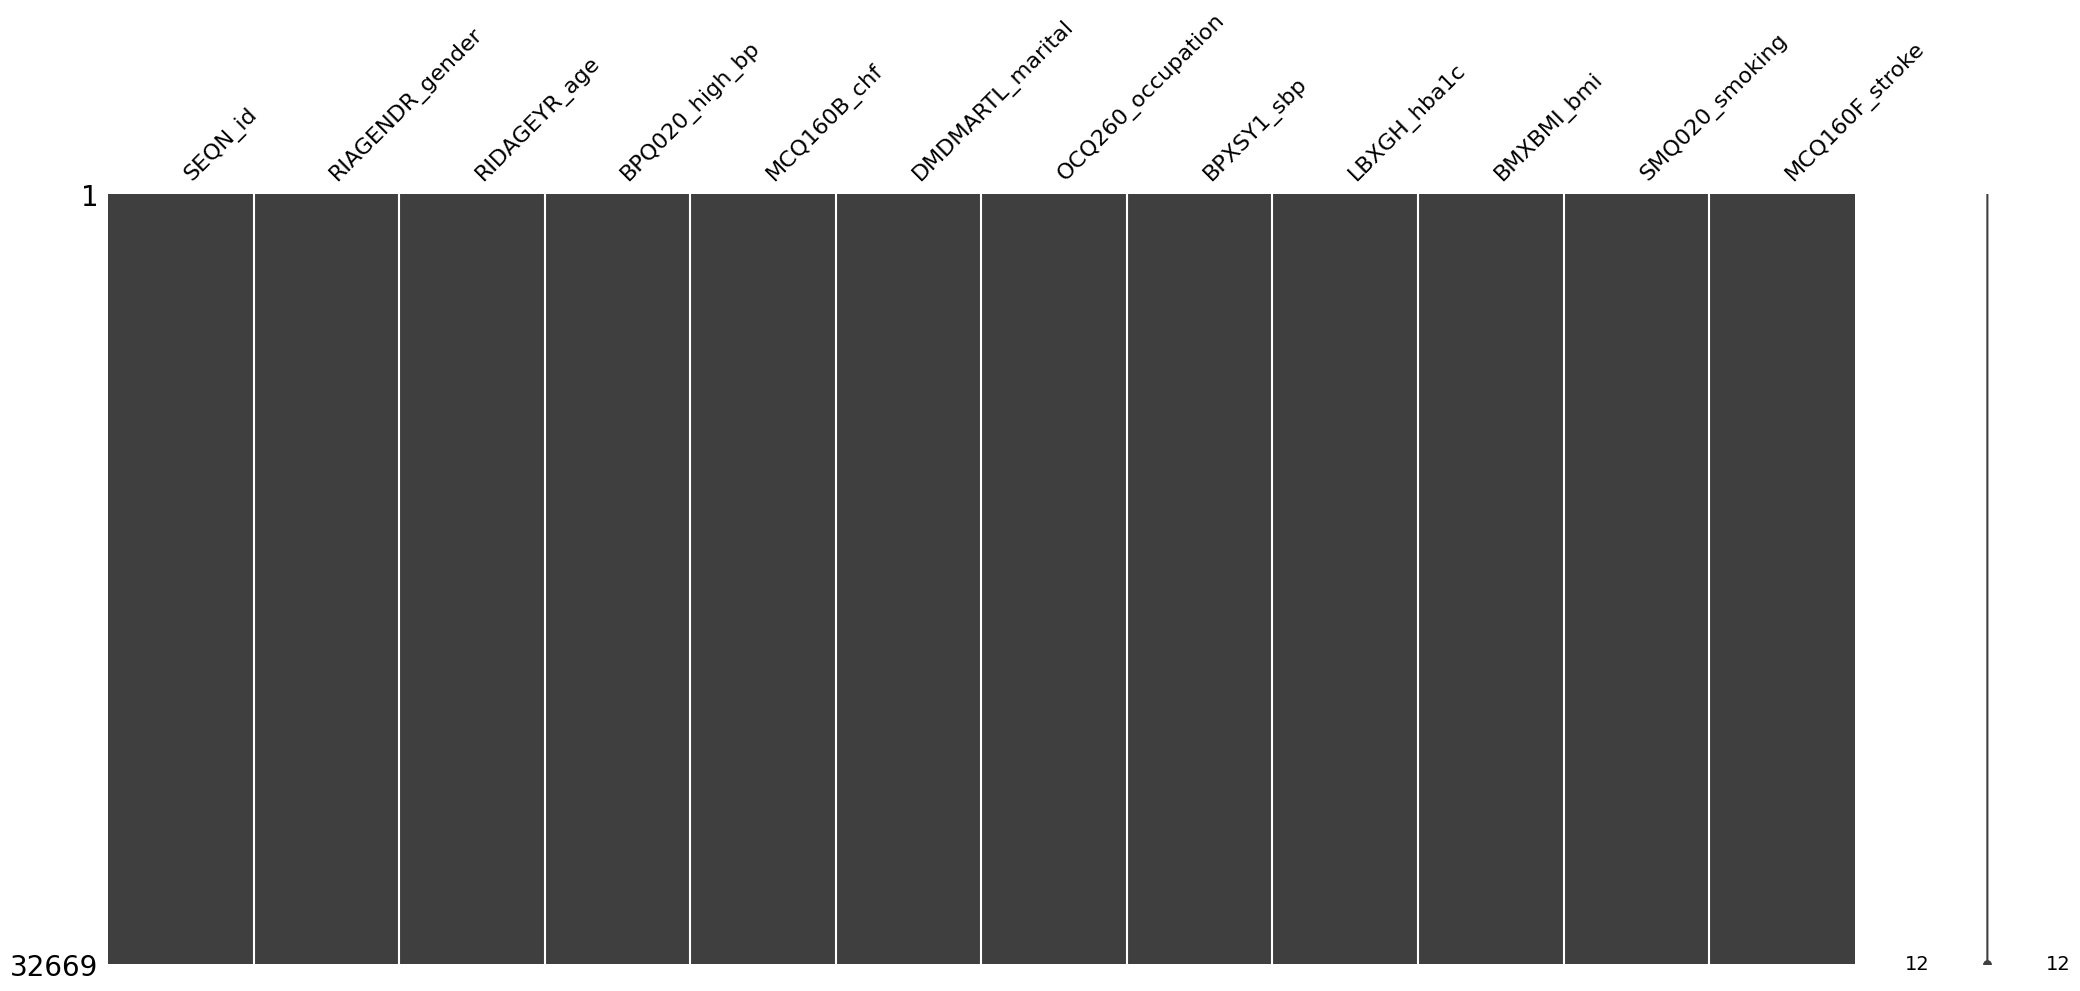

In [13]:
# visualizar o mapa de calor dos valores ausentes
msno.matrix(df)

In [14]:
# verificar os valores únicos da coluna alvo (original codes)
target_col = 'MCQ160F_stroke'

if target_col in df.columns:    print("Valores alvo unicos:", sorted(df[target_col].unique()))

Valores alvo unicos: [np.float64(1.0), np.float64(2.0)]


In [15]:
from sklearn.preprocessing import LabelBinarizer # importa o binarizador de rótulos do scikit-learn

# criar o binarizador
lb = LabelBinarizer()

# features categóricas para binarizar (1=Yes, 2=No -> 1, 0)
categorical_features = ['RIAGENDR_gender', 'BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking']
# binarizar as features categóricas
for col in categorical_features:
    if col in df.columns:
        # Filtrar apenas valores válidos (1, 2)
        df = df[df[col].isin([1, 2])].copy()
        
        # Transformar (2 vira 0, 1 permanece 1)
        binary_col = f"{col}_bin"
        df[binary_col] = df[col].map({1: 1, 2: 0})
        df = df.drop(columns=[col])
        
        print(f"\n{col} -> {binary_col}:")
        print(df[binary_col].value_counts())

# para DMDMARTL_marital: mapear para binário (já / nunca casou)
if 'DMDMARTL_marital' in df.columns:
    df = df[df['DMDMARTL_marital'].isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])].copy()
    df['DMDMARTL_married_bin'] = (df['DMDMARTL_marital'] != 5.0).astype(int)
    df = df.drop(columns=['DMDMARTL_marital'])
    
    print("\nDMDMARTL_marital -> DMDMARTL_married_bin:")
    print(df['DMDMARTL_married_bin'].value_counts())

df.head()



RIAGENDR_gender -> RIAGENDR_gender_bin:
RIAGENDR_gender_bin
0    16694
1    15975
Name: count, dtype: int64

BPQ020_high_bp -> BPQ020_high_bp_bin:
BPQ020_high_bp_bin
0    21204
1    11465
Name: count, dtype: int64

MCQ160B_chf -> MCQ160B_chf_bin:
MCQ160B_chf_bin
0    31639
1     1030
Name: count, dtype: int64

SMQ020_smoking -> SMQ020_smoking_bin:
SMQ020_smoking_bin
0    18055
1    14614
Name: count, dtype: int64

DMDMARTL_marital -> DMDMARTL_married_bin:
DMDMARTL_married_bin
1    26814
0     5842
Name: count, dtype: int64


,SEQN_id,RIDAGEYR_age,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,MCQ160F_stroke,RIAGENDR_gender_bin,BPQ020_high_bp_bin,MCQ160B_chf_bin,SMQ020_smoking_bin,DMDMARTL_married_bin
4,31131.0,44.0,1.0,144.0,6.0,30.90,2.0,0,1,1,0,1
5,31132.0,70.0,1.0,138.0,7.1,24.74,2.0,1,1,0,0,1
7,31134.0,73.0,0.0,130.0,5.9,30.63,2.0,1,1,0,0,1
17,31144.0,21.0,2.0,116.0,4.8,25.03,2.0,1,0,0,0,0
22,31149.0,85.0,0.0,110.0,5.6,21.63,2.0,0,1,0,0,1


In [16]:
# Manter só 1 (Yes) e 2 (No) no alvo e criar coluna binária 'MCQ160F_stroke_bin'
target_col = 'MCQ160F_stroke'
if target_col in df.columns:
    df = df[df[target_col].isin([1,2])].copy()
    df['MCQ160F_stroke_bin'] = df[target_col].map({1:1, 2:0})
    print("Counts (1=stroke,0=no):")
    print(df['MCQ160F_stroke_bin'].value_counts())
    
    # Remove a coluna original
    df = df.drop(columns=[target_col])


Counts (1=stroke,0=no):
MCQ160F_stroke_bin
0    31455
1     1201
Name: count, dtype: int64


In [17]:
# Resumo estatístico das colunas numéricas
df.describe()

,SEQN_id,RIDAGEYR_age,OCQ260_occupation,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,RIAGENDR_gender_bin,BPQ020_high_bp_bin,MCQ160B_chf_bin,SMQ020_smoking_bin,DMDMARTL_married_bin,MCQ160F_stroke_bin
count,32656.000000,32656.000000,32656.000000,32656.000000,32656.000000,32656.00000,32656.000000,32656.000000,32656.000000,32656.000000,32656.000000,32656.000000
mean,67832.806131,49.415268,1.280194,124.658991,5.749495,29.11239,0.489037,0.350931,0.031541,0.447360,0.821105,0.036777
std,20488.678069,17.785630,5.362351,18.941814,1.073893,6.85526,0.499887,0.477269,0.174777,0.497229,0.383270,0.188218
min,31131.000000,20.000000,0.000000,66.000000,2.000000,13.18000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50373.750000,34.000000,0.000000,112.000000,5.200000,24.33000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,67220.500000,49.000000,1.000000,122.000000,5.500000,28.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,85856.500000,64.000000,1.000000,134.000000,5.900000,32.50000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,102956.000000,85.000000,99.000000,270.000000,17.500000,130.21000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
df.shape

(32656, 12)

## Exploração de Dados (EDA)

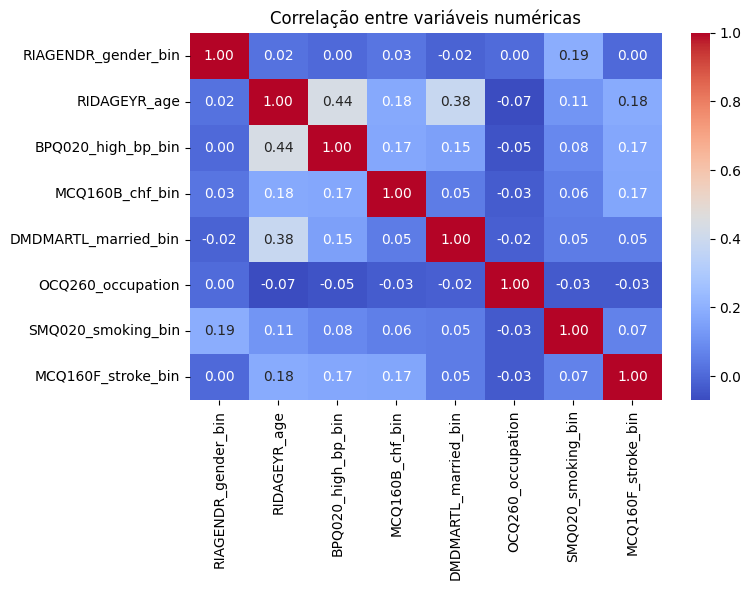

In [19]:
import matplotlib.pyplot as plt
import seaborn as sb

# heatmap de correlação (numéricas)
num_cols = ['RIAGENDR_gender_bin', 'RIDAGEYR_age', 'BPQ020_high_bp_bin', 'MCQ160B_chf_bin', 'DMDMARTL_married_bin', 'OCQ260_occupation', 'SMQ020_smoking_bin', 'MCQ160F_stroke_bin']

# manter apenas as colunas numéricas para a correlação (converter categorias em valores numéricos, se necessário).
corr_df = df[num_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(8,6))
sb.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas')
plt.tight_layout()

plt.show()


/tmp/ipykernel_8150/1596366555.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_rate = df.groupby('age_bin')['MCQ160F_stroke_bin'].mean().reset_index()
/tmp/ipykernel_8150/1596366555.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='age_bin', y='MCQ160F_stroke_bin', data=age_rate, palette='viridis')


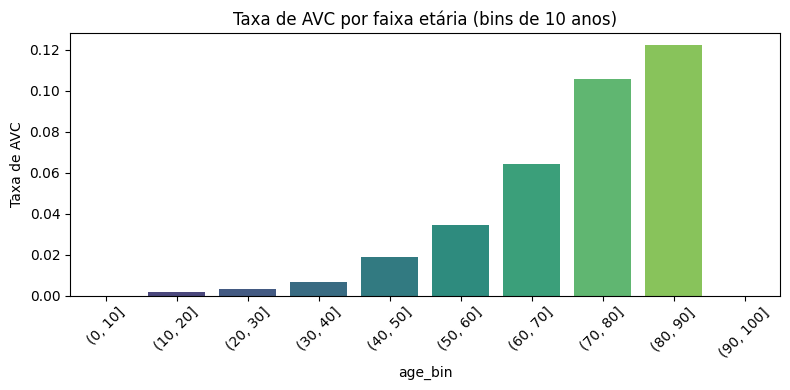

In [20]:
# taxa de AVC por faixa etária
df['age_bin'] = pd.cut(df['RIDAGEYR_age'], bins=range(0, 101, 10))
age_rate = df.groupby('age_bin')['MCQ160F_stroke_bin'].mean().reset_index()
plt.figure(figsize=(8,4))
sb.barplot(x='age_bin', y='MCQ160F_stroke_bin', data=age_rate, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel('Taxa de AVC')
plt.title('Taxa de AVC por faixa etária (bins de 10 anos)')
plt.tight_layout()
plt.show()

In [21]:
# taxa de AVC por variáveis categóricas (BPQ020_high_bp, MCQ160B_chf, SMQ020_smoking)
label_map = {1: 'Sim', 2: 'Não'}
for var in ['BPQ020_high_bp', 'MCQ160B_chf', 'SMQ020_smoking']:
    if var in df.columns:
        agg = df.groupby(var)['MCQ160F_stroke_bin'].agg(['count','sum']).reset_index()
        agg['rate'] = agg['sum'] / agg['count']
        plt.figure(figsize=(5,3))
        sb.barplot(x=var, y='rate', data=agg, palette='coolwarm')
        plt.xticks(ticks=range(len(agg[var])), labels=[label_map.get(int(v), v) for v in agg[var]])
        plt.ylim(0, agg['rate'].max()*1.15)
        plt.ylabel('Taxa de AVC')
        plt.title(f'Taxa de AVC por {var}')
        plt.tight_layout()
        plt.show()

array([[<Axes: title={'center': 'RIDAGEYR_age'}>,
        <Axes: title={'center': 'BPXSY1_sbp'}>],
       [<Axes: title={'center': 'LBXGH_hba1c'}>,
        <Axes: title={'center': 'BMXBMI_bmi'}>]], dtype=object)

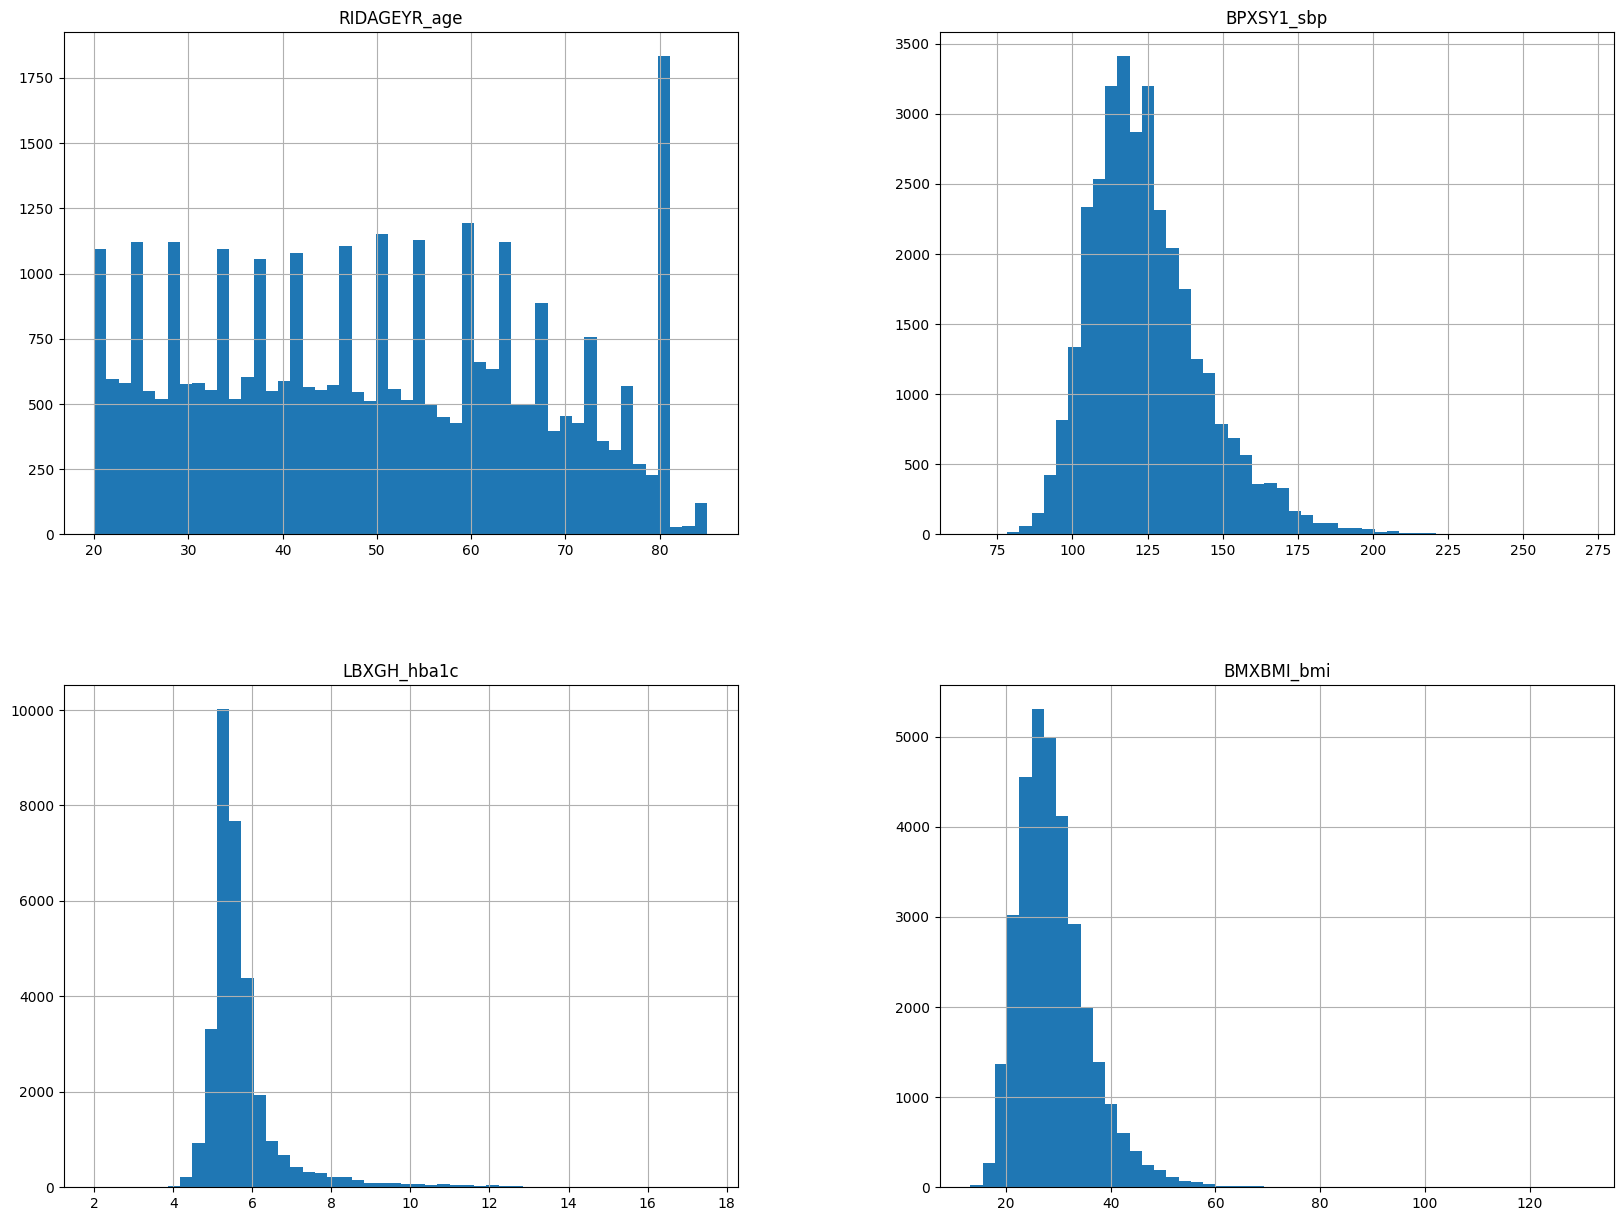

In [22]:
# distribuição das variáveis numéricas (selecionadas)
num_hist_cols = ['RIDAGEYR_age', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi']

# Ajustar layout e mostrar os histogramas
df[num_hist_cols].hist(bins=50, figsize=(20,15))

## Escolhendo os modelos e treinando

![Texto alternativo](./assets/logistic-regression-x-random-forest.png "Logistic Regression X Random Forest")

A ausência de correlações fortes (>0.70) entre features sugere que cada variável contribui com informação única para o modelo, favorecendo a performance de algoritmos lineares (Logistic Regression) e baseados em árvores (Random Forest). Este padrão justifica a manutenção de todas as features selecionadas na modelagem.

In [23]:

from sklearn.model_selection import train_test_split # importa a função de divisão de dados do scikit-learn
from sklearn.compose import ColumnTransformer # importa o transformador de colunas do scikit-learn
from sklearn.pipeline import Pipeline # importa a classe Pipeline do scikit-learn
from sklearn.impute import SimpleImputer # importa o imputador simples do scikit-learn
from sklearn.preprocessing import StandardScaler, OneHotEncoder # importa o escalador padrão e o codificador one-hot do scikit-learn
from sklearn.linear_model import LogisticRegression # importa o classificador de regressão logística do scikit-learn
from sklearn.ensemble import RandomForestClassifier # importa o classificador Random Forest do scikit-learn
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix # importa métricas de avaliação do scikit-learn

num_cols = ['RIDAGEYR_age', 'BPXSY1_sbp', 'LBXGH_hba1c', 'BMXBMI_bmi']
cat_cols = ['RIAGENDR_gender_bin', 'DMDMARTL_married_bin', 'BPQ020_high_bp_bin', 'MCQ160B_chf_bin', 'OCQ260_occupation', 'SMQ020_smoking_bin']

# eliminar linhas com alvo ausente
df_model = df.dropna(subset=['MCQ160F_stroke_bin']).copy()
X = df_model[num_cols + cat_cols]
y = df_model['MCQ160F_stroke_bin']

# dividir em treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# pipeline de pré-processamento
num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])

# combinar pipelines numéricos e categóricos
preproc = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

# pipelines dos modelos
pipe_lr = Pipeline([('pre', preproc), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
pipe_rf = Pipeline([('pre', preproc), ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))])

# treinar os modelos
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# avaliar os modelos no conjunto de teste
for name, model in [('LogisticRegression', pipe_lr), ('RandomForest', pipe_rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, y_prob))
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    print('PR AUC:', auc(recall, precision))
    print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

# importância da permutação (alternativa ao SHAP)
from sklearn.inspection import permutation_importance

# calcular a importância da permutação nas características transformadas (após o pré-processamento).
X_test_trans = preproc.transform(X_test)
r = permutation_importance(pipe_lr.named_steps['clf'], X_test_trans, y_test, n_repeats=30, random_state=42, scoring='roc_auc')
feat_names = preproc.get_feature_names_out()

# criar DataFrame de importâncias
imp_df = pd.DataFrame({'feature': feat_names, 'importance': r.importances_mean, 'std': r.importances_std})
imp_df = imp_df.sort_values('importance', ascending=False)

print('\nAs 10 principais características por importância de permutação (LogisticRegression, características transformadas):')
print(imp_df.head(10))

===== LogisticRegression =====
              precision    recall  f1-score   support

           0       0.99      0.75      0.85      6292
           1       0.11      0.79      0.19       240

    accuracy                           0.75      6532
   macro avg       0.55      0.77      0.52      6532
weighted avg       0.96      0.75      0.83      6532

ROC AUC: 0.8380390442890444
PR AUC: 0.1498803100239387
Confusion matrix:
 [[4698 1594]
 [  51  189]]
===== RandomForest =====
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      6292
           1       0.25      0.01      0.02       240

    accuracy                           0.96      6532
   macro avg       0.61      0.50      0.50      6532
weighted avg       0.94      0.96      0.95      6532

ROC AUC: 0.7720620761813943
PR AUC: 0.10854854938334232
Confusion matrix:
 [[6286    6]
 [ 238    2]]

As 10 principais características por importância de permutação (LogisticRegression, ca

## Parameter Tunning e Avaliação Final

/tmp/ipykernel_8150/545405015.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='classe_label', y='contagem', data=plot_df, palette=['#4c72b0', '#dd8452'])


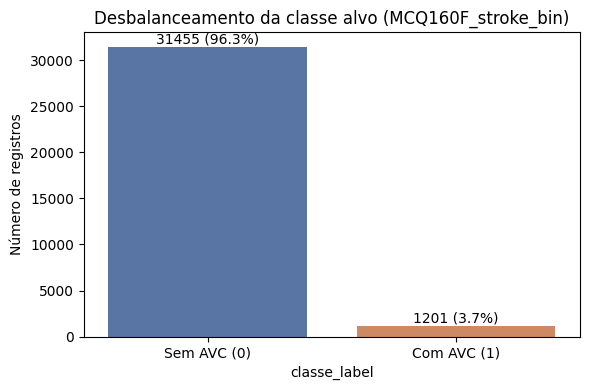

In [24]:
# distribuição da classe alvo para visualizar desbalanceamento
# usa df_model se disponível (alvo não nulo); caso contrário, usa df
dataset = df_model.copy() if 'df_model' in globals() and 'MCQ160F_stroke_bin' in df_model.columns else df[df['MCQ160F_stroke_bin'].notna()]

counts = dataset['MCQ160F_stroke_bin'].value_counts().reindex([0, 1], fill_value=0)
total = counts.sum()
plot_df = counts.reset_index()
plot_df.columns = ['classe', 'contagem']
label_map = {0: 'Sem AVC (0)', 1: 'Com AVC (1)'}
plot_df['classe_label'] = plot_df['classe'].map(label_map)

plt.figure(figsize=(6, 4))
sb.barplot(x='classe_label', y='contagem', data=plot_df, palette=['#4c72b0', '#dd8452'])
plt.ylabel('Número de registros')
plt.title('Desbalanceamento da classe alvo (MCQ160F_stroke_bin)')

# Anota contagens e porcentagens sobre as barras
for i, row in plot_df.iterrows():
    pct = (row['contagem'] / total) * 100 if total > 0 else 0
    plt.text(i, row['contagem'] + max(1, total * 0.01), f"{row['contagem']} ({pct:.1f}%)", ha='center')

plt.tight_layout()
plt.show()

In [25]:
# rebalanceamento por undersampling da classe majoritária
from sklearn.utils import resample

# separar as classes
df_major = df_model[df_model['MCQ160F_stroke_bin'] == 0]
df_minor = df_model[df_model['MCQ160F_stroke_bin'] == 1]

# reduzir classe majoritária para o tamanho da minoritária
df_major_down = resample(df_major, 
                         replace=False, 
                         n_samples=len(df_minor), 
                         random_state=42)

# concatenar e embaralhar
df_balanced = pd.concat([df_major_down, df_minor]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribuição após undersampling:")
print(df_balanced['MCQ160F_stroke_bin'].value_counts())

Distribuição após undersampling:
MCQ160F_stroke_bin
0    1201
1    1201
Name: count, dtype: int64


/tmp/ipykernel_8150/401863212.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='classe_label', y='contagem', data=plot_df, palette=['#4c72b0', '#dd8452'])


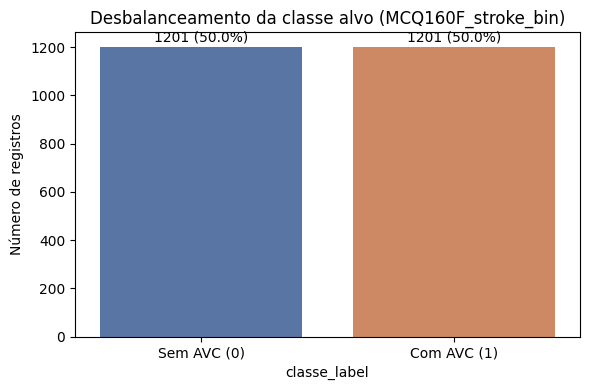

In [26]:
# distribuição da classe alvo para visualizar novo balanceamento
# usa df_model se disponível (alvo não nulo); caso contrário, usa df
dataset = df_balanced.copy() if 'df_balanced' in globals() and 'MCQ160F_stroke_bin' in df_balanced.columns else df[df['MCQ160F_stroke_bin'].notna()]

counts = dataset['MCQ160F_stroke_bin'].value_counts().reindex([0, 1], fill_value=0)
total = counts.sum()
plot_df = counts.reset_index()
plot_df.columns = ['classe', 'contagem']
label_map = {0: 'Sem AVC (0)', 1: 'Com AVC (1)'}
plot_df['classe_label'] = plot_df['classe'].map(label_map)

plt.figure(figsize=(6, 4))
sb.barplot(x='classe_label', y='contagem', data=plot_df, palette=['#4c72b0', '#dd8452'])
plt.ylabel('Número de registros')
plt.title('Desbalanceamento da classe alvo (MCQ160F_stroke_bin)')

# Anota contagens e porcentagens sobre as barras
for i, row in plot_df.iterrows():
    pct = (row['contagem'] / total) * 100 if total > 0 else 0
    plt.text(i, row['contagem'] + max(1, total * 0.01), f"{row['contagem']} ({pct:.1f}%)", ha='center')

plt.tight_layout()
plt.show()

In [27]:
# redefinir X e y
X_bal = df_balanced[num_cols + cat_cols]
y_bal = df_balanced['MCQ160F_stroke_bin']

# dividir em treino e teste
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(X_bal, y_bal, stratify=y_bal, test_size=0.2, random_state=42)

# treinar e avaliar ambos os modelos com base balanceada
for name, model in [('LogisticRegression', pipe_lr), ('RandomForest', pipe_rf)]:
    model.fit(X_train_bal, y_train_bal)
    y_pred_bal = model.predict(X_test_bal)
    y_prob_bal = model.predict_proba(X_test_bal)[:,1]
    
    print(f"===== {name} (base balanceada) =====")
    print(classification_report(y_test_bal, y_pred_bal))
    print('ROC AUC:', roc_auc_score(y_test_bal, y_prob_bal))
    precision, recall, _ = precision_recall_curve(y_test_bal, y_prob_bal)
    print('PR AUC:', auc(recall, precision))
    print('Confusion matrix:\n', confusion_matrix(y_test_bal, y_pred_bal))
    print()

# importância da permutação (alternativa ao SHAP)

# calcular a importância da permutação nas características transformadas (após o pré-processamento).
X_test_trans = preproc.transform(X_test_bal)
r = permutation_importance(pipe_lr.named_steps['clf'], X_test_trans, y_test_bal, n_repeats=30, random_state=42, scoring='roc_auc')
feat_names = preproc.get_feature_names_out()

# criar DataFrame de importâncias
imp_df = pd.DataFrame({'feature': feat_names, 'importance': r.importances_mean, 'std': r.importances_std})
imp_df = imp_df.sort_values('importance', ascending=False)

print('\nAs 10 principais características por importância de permutação (LogisticRegression, características transformadas):')
print(imp_df.head(10))

===== LogisticRegression (base balanceada) =====
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       241
           1       0.74      0.75      0.74       240

    accuracy                           0.74       481
   macro avg       0.74      0.74      0.74       481
weighted avg       0.74      0.74      0.74       481

ROC AUC: 0.8131742738589212
PR AUC: 0.7819746771304927
Confusion matrix:
 [[178  63]
 [ 61 179]]

===== RandomForest (base balanceada) =====
              precision    recall  f1-score   support

           0       0.72      0.71      0.71       241
           1       0.71      0.73      0.72       240

    accuracy                           0.72       481
   macro avg       0.72      0.72      0.72       481
weighted avg       0.72      0.72      0.72       481

ROC AUC: 0.7997320193637621
PR AUC: 0.7809895864233712
Confusion matrix:
 [[170  71]
 [ 65 175]]


As 10 principais características por importância de permu

# Tech Challenge - Fase 2

* [Documentaçao do projeto](https://github.com/paulosobral/fiap-pos-tech-ia-para-devs/blob/main/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/README.md "Tech Challenge - Fase 2 GA e Núvem")

* [Vídeo de apresentação do projeto](https://youtu.be/gmO5QkQ1pzQ "Tech Challenge - Fase 2 GA")
* [Vídeo EXTRA de apresentação do projeto](https://youtu.be/liI0857GuMs "Tech Challenge - Fase 2 Núvem")

## Otimização de Hiperparâmetros com Algoritmo Genético

A otimização por algoritmo genético (GA) é uma técnica inspirada na evolução biológica que busca encontrar soluções ótimas através de:

- **Seleção**: Indivíduos mais aptos (melhores hiperparâmetros) têm maior chance de reprodução
- **Crossover**: Combinação de características de dois "pais" para gerar "filhos"
- **Mutação**: Alterações aleatórias para explorar novas regiões do espaço de busca
- **Elitismo**: Preservação dos melhores indivíduos entre gerações

### Objetivo
Maximizar o **F-beta Score (β=1.5)**, que dá peso maior ao **Recall** (detectar casos de AVC) sem ignorar a **Precision** (evitar alarmes falsos).
Modelos com Precision < 0.3 são penalizados com score zero para evitar soluções degeneradas (ex: classificar tudo como positivo).

### Experimento 1 — GASearchCV (sklearn-genetic-opt)

Utiliza a biblioteca `sklearn-genetic-opt` para busca automatizada de hiperparâmetros via algoritmo genético.

| Parâmetro | Valor |
|---|---|
| População | 15 |
| Gerações | 10 |
| Taxa de crossover | 0.8 |
| Taxa de mutação | 0.1 |
| Seleção | Torneio (k=3) |
| Elitismo | Sim |
| Fitness | F-beta (β=1.5) com penalidade de precisão |

In [28]:
# Instalar sklearn-genetic-opt se necessário
# !pip install sklearn-genetic-opt

from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Categorical, Integer, Continuous
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score, fbeta_score

# Preparar dados para busca genética
X_bal = df_balanced[num_cols + cat_cols]
y_bal = df_balanced['MCQ160F_stroke_bin']

# Dividir em treino e teste
X_train_ga, X_test_ga, y_train_ga, y_test_ga = train_test_split(
    X_bal, y_bal, stratify=y_bal, test_size=0.2, random_state=42
)

# Scorer customizado: usa F-beta (beta=1.5) para privilegiar recall sobre precision,
# mas com penalidade para modelos degenerados (precision < 0.3).
# Isso evita soluções triviais que classificam tudo como positivo (recall=1, precision~0.5).
def custom_scorer(y_true, y_pred):
    prec = precision_score(y_true, y_pred, zero_division=0)
    if prec < 0.3:
        return 0.0
    return fbeta_score(y_true, y_pred, beta=1.5, zero_division=0)

scorer = make_scorer(custom_scorer)

# Espaço de busca para Logistic Regression
param_grid_lr = {
    'clf__C': Continuous(0.001, 100, distribution='log-uniform'),
    'clf__penalty': Categorical(['l1', 'l2']),
    'clf__solver': Categorical(['liblinear', 'saga']),
    'clf__max_iter': Integer(100, 2000)
}

# Espaço de busca para Random Forest
param_grid_rf = {
    'clf__n_estimators': Integer(50, 300),
    'clf__max_depth': Integer(3, 20),
    'clf__min_samples_split': Integer(2, 15),
    'clf__min_samples_leaf': Integer(1, 8),
    'clf__max_features': Categorical(['sqrt', 'log2', None])
}

print("Iniciando otimização genética...")
print("=" * 60)

Iniciando otimização genética...


In [29]:
# Otimização Genética para Logistic Regression
print("=== Otimização Genética - Logistic Regression ===\n")

ga_lr = GASearchCV(
    estimator=pipe_lr,
    cv=3,  # cross-validation com 3 folds para acelerar
    scoring=scorer,
    param_grid=param_grid_lr,
    population_size=15,      # número de soluções por geração
    generations=10,          # número de iterações evolutivas
    tournament_size=3,       # indivíduos competindo na seleção
    elitism=True,            # preserva os melhores indivíduos
    crossover_probability=0.8,  # chance de combinar genes de dois pais
    mutation_probability=0.1,   # chance de alteração aleatória
    n_jobs=-1,               # usar todos os cores disponíveis
    verbose=True
)

ga_lr.fit(X_train_ga, y_train_ga)

print(f"\n{'='*60}")
print(f"Melhores hiperparâmetros (Logistic Regression):")
for param, value in ga_lr.best_params_.items():
    print(f"  {param}: {value}")
print(f"Melhor score (treino CV): {ga_lr.best_score_:.4f}")

=== Otimização Genética - Logistic Regression ===



/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	15    	0.678704	0.266355   	0.793239   	0          
1  	30    	0.785498	0.00969996 	0.794452   	0.751897   


/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao

2  	28    	0.790952	0.00202453 	0.794452   	0.788214   
3  	27    	0.792132	0.00207065 	0.794452   	0.789502   
4  	27    	0.795092	0.00287361 	0.802283   	0.793239   
5  	25    	0.79654 	0.00346318 	0.802283   	0.794452   
6  	29    	0.798106	0.00390699 	0.802283   	0.794452   
7  	24    	0.802283	2.22045e-16	0.802283   	0.802283   
8  	28    	0.802283	2.22045e-16	0.802283   	0.802283   
9  	25    	0.802283	2.22045e-16	0.802283   	0.802283   
10 	27    	0.802283	2.22045e-16	0.802283   	0.802283   

Melhores hiperparâmetros (Logistic Regression):
  clf__C: 0.0013169695896238587
  clf__penalty: l2
  clf__solver: liblinear
  clf__max_iter: 575
Melhor score (treino CV): 0.8025


In [30]:
# Otimização Genética para Random Forest
print("=== Otimização Genética - Random Forest ===\n")

ga_rf = GASearchCV(
    estimator=pipe_rf,
    cv=3,
    scoring=scorer,
    param_grid=param_grid_rf,
    population_size=15,
    generations=10,
    tournament_size=3,
    elitism=True,
    crossover_probability=0.8,
    mutation_probability=0.1,
    n_jobs=-1,
    verbose=True
)

ga_rf.fit(X_train_ga, y_train_ga)

print(f"\n{'='*60}")
print(f"Melhores hiperparâmetros (Random Forest):")
for param, value in ga_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"Melhor score (treino CV): {ga_rf.best_score_:.4f}")

=== Otimização Genética - Random Forest ===

gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	15    	0.78106	0.00642955 	0.788903   	0.769878   
1  	28    	0.785339	0.00329604 	0.789867   	0.776032   
2  	27    	0.787008	0.00120568 	0.788903   	0.785589   
3  	25    	0.787938	0.000966369	0.789373   	0.785955   
4  	24    	0.789664	0.00138144 	0.793007   	0.787944   
5  	27    	0.790756	0.00154815 	0.793007   	0.788266   
6  	29    	0.7912  	0.00156007 	0.793007   	0.788292   
7  	26    	0.792257	0.00116148 	0.793007   	0.78912    
8  	24    	0.792505	0.00109081 	0.793007   	0.789153   
9  	26    	0.792884	0.000459438	0.793007   	0.791165   
10 	28    	0.793007	2.22045e-16	0.793007   	0.793007   

Melhores hiperparâmetros (Random Forest):
  clf__n_estimators: 83
  clf__max_depth: 10
  clf__min_samples_split: 9
  clf__min_samples_leaf: 4
  clf__max_features: log2
Melhor score (treino CV): 0.7930


### Experimento 2 — Algoritmo Genético Manual (População Grande, Mutação Baixa)

Implementação **from scratch** do algoritmo genético, sem uso de bibliotecas externas de GA.
Cada indivíduo é um vetor de hiperparâmetros codificados; os operadores de **seleção por torneio**,
**crossover uniforme** e **mutação gaussiana/aleatória** são aplicados manualmente.

| Parâmetro | Valor |
|---|---|
| População | 30 |
| Gerações | 15 |
| Taxa de crossover | 0.9 |
| Taxa de mutação | 0.05 |
| Seleção | Torneio (k=5) |
| Elitismo | Top 2 |
| Fitness | F-beta (β=1.5) com penalidade de precisão |

In [31]:
import numpy as np
from copy import deepcopy
from sklearn.model_selection import cross_val_score

# ========================================================================
# ALGORITMO GENÉTICO MANUAL — Funções auxiliares
# ========================================================================

def encode_individual_lr(rng):
    """Cria um indivíduo (vetor de genes) para Logistic Regression.
    Genes: [C (log-space), penalty_idx, solver_idx, max_iter]"""
    C = 10 ** rng.uniform(-3, 2)          # C em log-scale: 0.001 a 100
    penalty_idx = rng.integers(0, 2)       # 0='l1', 1='l2'
    solver_idx = rng.integers(0, 2)        # 0='liblinear', 1='saga'
    max_iter = rng.integers(100, 2001)     # 100 a 2000
    return [C, penalty_idx, solver_idx, max_iter]

def decode_individual_lr(ind):
    """Decodifica um indivíduo em dict de hiperparâmetros para Logistic Regression."""
    penalties = ['l1', 'l2']
    solvers = ['liblinear', 'saga']
    return {
        'clf__C': ind[0],
        'clf__penalty': penalties[int(ind[1])],
        'clf__solver': solvers[int(ind[2])],
        'clf__max_iter': int(ind[3])
    }

def encode_individual_rf(rng):
    """Cria um indivíduo para Random Forest.
    Genes: [n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features_idx]"""
    n_est = rng.integers(50, 301)
    max_d = rng.integers(3, 21)
    min_split = rng.integers(2, 16)
    min_leaf = rng.integers(1, 9)
    max_feat_idx = rng.integers(0, 3)  # 0='sqrt', 1='log2', 2=None
    return [n_est, max_d, min_split, min_leaf, max_feat_idx]

def decode_individual_rf(ind):
    """Decodifica um indivíduo em dict de hiperparâmetros para Random Forest."""
    max_features_opts = ['sqrt', 'log2', None]
    return {
        'clf__n_estimators': int(ind[0]),
        'clf__max_depth': int(ind[1]),
        'clf__min_samples_split': int(ind[2]),
        'clf__min_samples_leaf': int(ind[3]),
        'clf__max_features': max_features_opts[int(ind[4])]
    }

def evaluate_fitness(pipeline, params, X, y, cv=3):
    """Avalia o fitness de um indivíduo usando cross-validation com o scorer customizado."""
    pipe = deepcopy(pipeline)
    pipe.set_params(**params)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    return np.mean(scores)

def tournament_selection(population, fitnesses, k, rng):
    """Seleção por torneio: escolhe k indivíduos aleatórios e retorna o melhor."""
    indices = rng.choice(len(population), size=k, replace=False)
    best_idx = indices[np.argmax([fitnesses[i] for i in indices])]
    return deepcopy(population[best_idx])

def uniform_crossover(parent1, parent2, prob, rng):
    """Crossover uniforme: cada gene é herdado de um dos pais com probabilidade 'prob'."""
    if rng.random() > prob:
        return deepcopy(parent1), deepcopy(parent2)
    child1, child2 = deepcopy(parent1), deepcopy(parent2)
    for i in range(len(parent1)):
        if rng.random() < 0.5:
            child1[i], child2[i] = child2[i], child1[i]
    return child1, child2

def mutate_lr(ind, prob, rng):
    """Mutação para Logistic Regression: aplica perturbação gaussiana ou re-sorteia genes."""
    ind = deepcopy(ind)
    if rng.random() < prob:
        ind[0] = np.clip(ind[0] * 10**rng.normal(0, 0.5), 0.001, 100)  # C
    if rng.random() < prob:
        ind[1] = rng.integers(0, 2)  # penalty
    if rng.random() < prob:
        ind[2] = rng.integers(0, 2)  # solver
    if rng.random() < prob:
        ind[3] = np.clip(ind[3] + rng.integers(-200, 201), 100, 2000)  # max_iter
    return ind

def mutate_rf(ind, prob, rng):
    """Mutação para Random Forest: aplica perturbação inteira ou re-sorteia genes."""
    ind = deepcopy(ind)
    if rng.random() < prob:
        ind[0] = np.clip(ind[0] + rng.integers(-50, 51), 50, 300)  # n_estimators
    if rng.random() < prob:
        ind[1] = np.clip(ind[1] + rng.integers(-3, 4), 3, 20)  # max_depth
    if rng.random() < prob:
        ind[2] = np.clip(ind[2] + rng.integers(-3, 4), 2, 15)  # min_samples_split
    if rng.random() < prob:
        ind[3] = np.clip(ind[3] + rng.integers(-2, 3), 1, 8)  # min_samples_leaf
    if rng.random() < prob:
        ind[4] = rng.integers(0, 3)  # max_features
    return ind

def run_ga_manual(pipeline, encode_fn, decode_fn, mutate_fn, X, y,
                  pop_size, n_gen, crossover_prob, mutation_prob,
                  tournament_k, n_elite, seed=42):
    """Executa o algoritmo genético manual completo.
    
    Retorna: (melhor_params, melhor_fitness, histórico_por_geração)
    """
    rng = np.random.default_rng(seed)
    
    # Inicializar população
    population = [encode_fn(rng) for _ in range(pop_size)]
    
    history = {'fitness_max': [], 'fitness_mean': [], 'fitness_min': [], 'best_params': []}
    best_ever_fitness = -np.inf
    best_ever_params = None
    
    for gen in range(n_gen):
        # Avaliar fitness de toda a população
        fitnesses = []
        for ind in population:
            params = decode_fn(ind)
            fit = evaluate_fitness(pipeline, params, X, y)
            fitnesses.append(fit)
        fitnesses = np.array(fitnesses)
        
        # Registrar histórico
        history['fitness_max'].append(float(np.max(fitnesses)))
        history['fitness_mean'].append(float(np.mean(fitnesses)))
        history['fitness_min'].append(float(np.min(fitnesses)))
        
        # Atualizar melhor global
        gen_best_idx = np.argmax(fitnesses)
        if fitnesses[gen_best_idx] > best_ever_fitness:
            best_ever_fitness = fitnesses[gen_best_idx]
            best_ever_params = decode_fn(population[gen_best_idx])
        
        history['best_params'].append(deepcopy(best_ever_params))
        
        print(f"  Geração {gen+1:2d}/{n_gen}: "
              f"max={np.max(fitnesses):.4f}  média={np.mean(fitnesses):.4f}  "
              f"min={np.min(fitnesses):.4f}")
        
        # Elitismo: preservar os N melhores
        elite_indices = np.argsort(fitnesses)[-n_elite:]
        elites = [deepcopy(population[i]) for i in elite_indices]
        
        # Gerar nova população
        new_population = list(elites)  # começa com os elites
        
        while len(new_population) < pop_size:
            # Seleção
            p1 = tournament_selection(population, fitnesses, tournament_k, rng)
            p2 = tournament_selection(population, fitnesses, tournament_k, rng)
            
            # Crossover
            c1, c2 = uniform_crossover(p1, p2, crossover_prob, rng)
            
            # Mutação
            c1 = mutate_fn(c1, mutation_prob, rng)
            c2 = mutate_fn(c2, mutation_prob, rng)
            
            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)
        
        population = new_population[:pop_size]
    
    return best_ever_params, best_ever_fitness, history

print("Funções do Algoritmo Genético manual definidas com sucesso.")

Funções do Algoritmo Genético manual definidas com sucesso.


In [32]:
# ========================================================================
# EXPERIMENTO 2 — GA Manual: População Grande (30), Mutação Baixa (0.05)
# ========================================================================
print("=" * 60)
print("EXPERIMENTO 2 — GA Manual (pop=30, mut=0.05, cx=0.9)")
print("=" * 60)

# --- Logistic Regression ---
print("\n--- Logistic Regression ---")
best_params_lr_exp2, best_fit_lr_exp2, hist_lr_exp2 = run_ga_manual(
    pipeline=pipe_lr,
    encode_fn=encode_individual_lr,
    decode_fn=decode_individual_lr,
    mutate_fn=mutate_lr,
    X=X_train_ga, y=y_train_ga,
    pop_size=30,
    n_gen=15,
    crossover_prob=0.9,
    mutation_prob=0.05,
    tournament_k=5,
    n_elite=2,
    seed=42
)

print(f"\nMelhores hiperparâmetros (LR Exp2): {best_params_lr_exp2}")
print(f"Melhor fitness (LR Exp2): {best_fit_lr_exp2:.4f}")

# Treinar modelo final com os melhores hiperparâmetros
pipe_lr_exp2 = deepcopy(pipe_lr)
pipe_lr_exp2.set_params(**best_params_lr_exp2)
pipe_lr_exp2.fit(X_train_ga, y_train_ga)

# --- Random Forest ---
print("\n--- Random Forest ---")
best_params_rf_exp2, best_fit_rf_exp2, hist_rf_exp2 = run_ga_manual(
    pipeline=pipe_rf,
    encode_fn=encode_individual_rf,
    decode_fn=decode_individual_rf,
    mutate_fn=mutate_rf,
    X=X_train_ga, y=y_train_ga,
    pop_size=30,
    n_gen=15,
    crossover_prob=0.9,
    mutation_prob=0.05,
    tournament_k=5,
    n_elite=2,
    seed=42
)

print(f"\nMelhores hiperparâmetros (RF Exp2): {best_params_rf_exp2}")
print(f"Melhor fitness (RF Exp2): {best_fit_rf_exp2:.4f}")

# Treinar modelo final com os melhores hiperparâmetros
pipe_rf_exp2 = deepcopy(pipe_rf)
pipe_rf_exp2.set_params(**best_params_rf_exp2)
pipe_rf_exp2.fit(X_train_ga, y_train_ga)

EXPERIMENTO 2 — GA Manual (pop=30, mut=0.05, cx=0.9)

--- Logistic Regression ---


/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Geração  1/15: max=0.8015  média=0.7514  min=0.0000
  Geração  2/15: max=0.8015  média=0.7885  min=0.7348
  Geração  3/15: max=0.8015  média=0.7986  min=0.7348
  Geração  4/15: max=0.8015  média=0.7992  min=0.7379
  Geração  5/15: max=0.8015  média=0.7994  min=0.7379
  Geração  6/15: max=0.8015  média=0.7994  min=0.7379
  Geração  7/15: max=0.8015  média=0.8015  min=0.8015
  Geração  8/15: max=0.8015  média=0.7991  min=0.7379
  Geração  9/15: max=0.8015  média=0.7994  min=0.7379
  Geração 10/15: max=0.8037  média=0.7994  min=0.7379
  Geração 11/15: max=0.8037  média=0.8019  min=0.7958
  Geração 12/15: max=0.8045  média=0.7989  min=0.7379
  Geração 13/15: max=0.8045  média=0.8036  min=0.7998
  Geração 14/15: max=0.8045  média=0.7774  min=0.0000
  Geração 15/15: max=0.8045  média=0.8015  min=0.7379

Melhores hiperparâmetros (LR Exp2): {'clf__C': np.float64(0.0034144742436208017), 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'clf__max_iter': 1614}
Melhor fitness (LR Exp2): 0.8045



,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Experimento 3 — Algoritmo Genético Manual (População Pequena, Mutação Alta)

Mesma implementação manual, porém com configuração focada em **exploração agressiva**:
população menor para iterações mais rápidas, taxa de mutação mais alta para escapar de ótimos locais,
e torneio menor para manter diversidade.

| Parâmetro | Valor |
|---|---|
| População | 10 |
| Gerações | 20 |
| Taxa de crossover | 0.7 |
| Taxa de mutação | 0.25 |
| Seleção | Torneio (k=3) |
| Elitismo | Top 1 |
| Fitness | F-beta (β=1.5) com penalidade de precisão |

In [33]:
# ========================================================================
# EXPERIMENTO 3 — GA Manual: População Pequena (10), Mutação Alta (0.25)
# ========================================================================
print("=" * 60)
print("EXPERIMENTO 3 — GA Manual (pop=10, mut=0.25, cx=0.7)")
print("=" * 60)

# --- Logistic Regression ---
print("\n--- Logistic Regression ---")
best_params_lr_exp3, best_fit_lr_exp3, hist_lr_exp3 = run_ga_manual(
    pipeline=pipe_lr,
    encode_fn=encode_individual_lr,
    decode_fn=decode_individual_lr,
    mutate_fn=mutate_lr,
    X=X_train_ga, y=y_train_ga,
    pop_size=10,
    n_gen=20,
    crossover_prob=0.7,
    mutation_prob=0.25,
    tournament_k=3,
    n_elite=1,
    seed=123
)

print(f"\nMelhores hiperparâmetros (LR Exp3): {best_params_lr_exp3}")
print(f"Melhor fitness (LR Exp3): {best_fit_lr_exp3:.4f}")

# Treinar modelo final
pipe_lr_exp3 = deepcopy(pipe_lr)
pipe_lr_exp3.set_params(**best_params_lr_exp3)
pipe_lr_exp3.fit(X_train_ga, y_train_ga)

# --- Random Forest ---
print("\n--- Random Forest ---")
best_params_rf_exp3, best_fit_rf_exp3, hist_rf_exp3 = run_ga_manual(
    pipeline=pipe_rf,
    encode_fn=encode_individual_rf,
    decode_fn=decode_individual_rf,
    mutate_fn=mutate_rf,
    X=X_train_ga, y=y_train_ga,
    pop_size=10,
    n_gen=20,
    crossover_prob=0.7,
    mutation_prob=0.25,
    tournament_k=3,
    n_elite=1,
    seed=123
)

print(f"\nMelhores hiperparâmetros (RF Exp3): {best_params_rf_exp3}")
print(f"Melhor fitness (RF Exp3): {best_fit_rf_exp3:.4f}")

# Treinar modelo final
pipe_rf_exp3 = deepcopy(pipe_rf)
pipe_rf_exp3.set_params(**best_params_rf_exp3)
pipe_rf_exp3.fit(X_train_ga, y_train_ga)

EXPERIMENTO 3 — GA Manual (pop=10, mut=0.25, cx=0.7)

--- Logistic Regression ---


/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Geração  1/20: max=0.7948  média=0.7775  min=0.7379


/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/psobral89/Workspaces/fiap/fiap-pos-tech-ia-para-devs/01-aulas-gravadas/02-evolucao-da-ia-genia-cloud-ml-e-llms/07-tech-challenge/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Geração  2/20: max=0.7948  média=0.7872  min=0.7836
  Geração  3/20: max=0.8012  média=0.7874  min=0.7369
  Geração  4/20: max=0.8030  média=0.7913  min=0.7369
  Geração  5/20: max=0.8030  média=0.7979  min=0.7858
  Geração  6/20: max=0.8030  média=0.7958  min=0.7379
  Geração  7/20: max=0.8030  média=0.6409  min=0.0000
  Geração  8/20: max=0.8030  média=0.5621  min=0.0000
  Geração  9/20: max=0.8030  média=0.7212  min=0.0000
  Geração 10/20: max=0.8037  média=0.8010  min=0.7934
  Geração 11/20: max=0.8045  média=0.8035  min=0.8028
  Geração 12/20: max=0.8045  média=0.7163  min=0.0000
  Geração 13/20: max=0.8045  média=0.7225  min=0.0000
  Geração 14/20: max=0.8045  média=0.7215  min=0.0000
  Geração 15/20: max=0.8045  média=0.7911  min=0.7379
  Geração 16/20: max=0.8045  média=0.7976  min=0.7379
  Geração 17/20: max=0.8045  média=0.7822  min=0.7379
  Geração 18/20: max=0.8045  média=0.7961  min=0.7379
  Geração 19/20: max=0.8045  média=0.7954  min=0.7379
  Geração 20/20: max=0.8045 

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Comparativo dos 3 Experimentos de Algoritmo Genético

Seleção do melhor experimento GA para cada modelo (LR e RF) com base na **média de F1-Score e Recall** no conjunto de teste.
O vencedor de cada modelo é utilizado nas células seguintes para comparação final com os modelos originais.

COMPARATIVO DOS 3 EXPERIMENTOS DE ALGORITMO GENÉTICO

        Tipo Modelo                                  Experimento  Precision   Recall  F1-Score  ROC-AUC  Média (F1+Recall)/2
Logistic Regression Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)   0.693950 0.812500  0.748560 0.801331             0.780530
Logistic Regression           Exp2 (GA Manual, pop=30, mut=0.05)   0.698182 0.800000  0.745631 0.804703             0.772816
Logistic Regression           Exp3 (GA Manual, pop=10, mut=0.25)   0.698182 0.800000  0.745631 0.804685             0.772816
      Random Forest Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)   0.722222 0.758333  0.739837 0.811463             0.749085
      Random Forest           Exp2 (GA Manual, pop=30, mut=0.05)   0.716535 0.758333  0.736842 0.813192             0.747588
      Random Forest           Exp3 (GA Manual, pop=10, mut=0.25)   0.725490 0.770833  0.747475 0.813555             0.759154

MELHOR GA para Logistic Regression: Exp1 (sklearn-genetic-opt, pop=15,

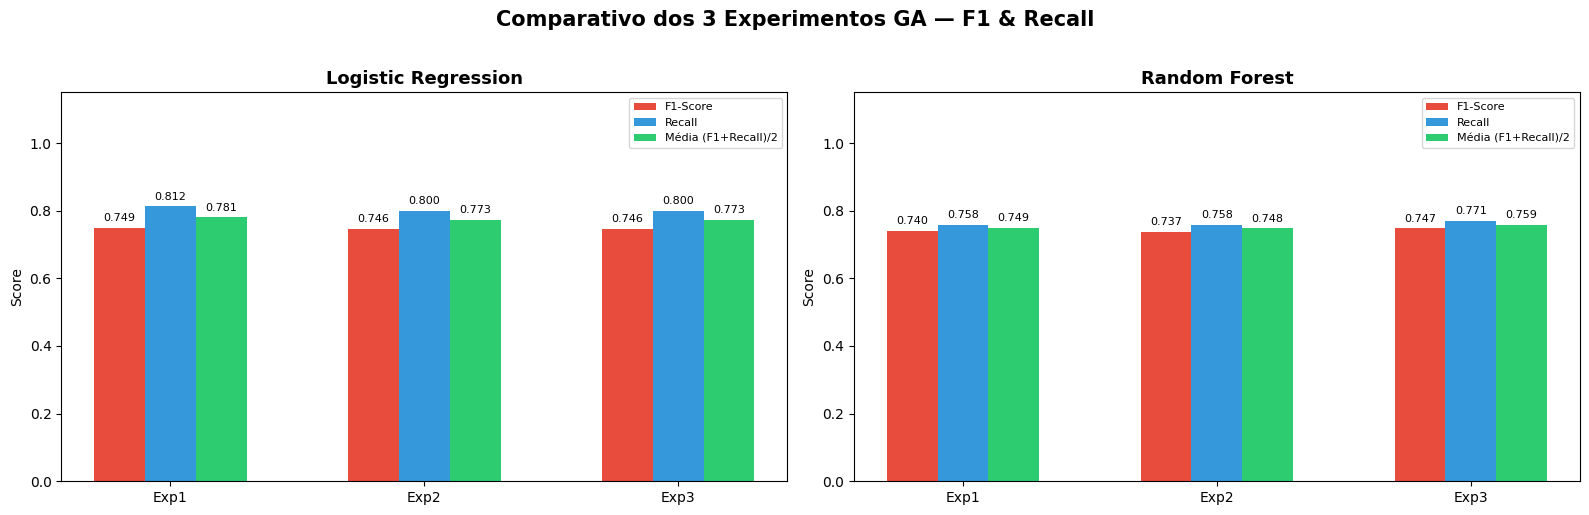

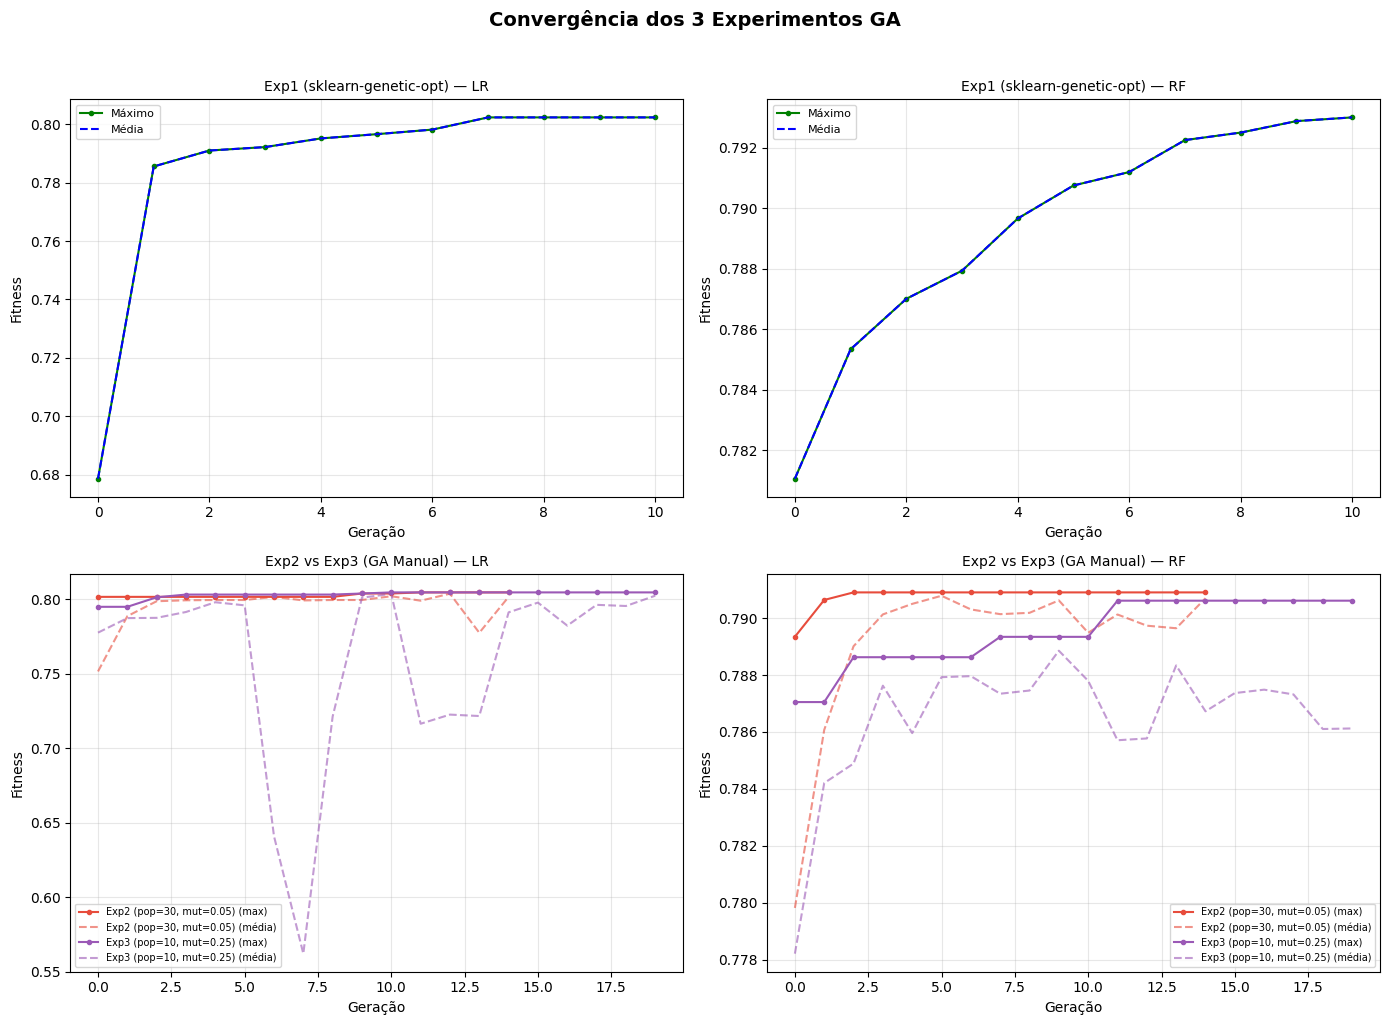

In [34]:
# ========================================================================
# COMPARATIVO DOS 3 EXPERIMENTOS GA — Selecionar o melhor para cada modelo
# ========================================================================
print("=" * 70)
print("COMPARATIVO DOS 3 EXPERIMENTOS DE ALGORITMO GENÉTICO")
print("=" * 70)

# Dicionário com todos os modelos GA treinados, agrupados por tipo
ga_experiments = {
    'Logistic Regression': {
        'Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)': ga_lr,
        'Exp2 (GA Manual, pop=30, mut=0.05)': pipe_lr_exp2,
        'Exp3 (GA Manual, pop=10, mut=0.25)': pipe_lr_exp3,
    },
    'Random Forest': {
        'Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)': ga_rf,
        'Exp2 (GA Manual, pop=30, mut=0.05)': pipe_rf_exp2,
        'Exp3 (GA Manual, pop=10, mut=0.25)': pipe_rf_exp3,
    }
}

ga_comparison_rows = []

for model_type, experiments in ga_experiments.items():
    for exp_name, model in experiments.items():
        y_pred = model.predict(X_test_ga)
        y_prob = model.predict_proba(X_test_ga)[:, 1]
        
        rec = recall_score(y_test_ga, y_pred)
        f1 = f1_score(y_test_ga, y_pred)
        prec = precision_score(y_test_ga, y_pred)
        roc = roc_auc_score(y_test_ga, y_prob)
        
        ga_comparison_rows.append({
            'Tipo Modelo': model_type,
            'Experimento': exp_name,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'ROC-AUC': roc,
            'Média (F1+Recall)/2': (f1 + rec) / 2,
        })

ga_comp_df = pd.DataFrame(ga_comparison_rows)

# Exibir tabela completa
print("\n" + ga_comp_df.to_string(index=False))

# --- Selecionar o melhor experimento para cada tipo de modelo ---
best_ga_lr_row = ga_comp_df[ga_comp_df['Tipo Modelo'] == 'Logistic Regression'] \
    .sort_values('Média (F1+Recall)/2', ascending=False).iloc[0]
best_ga_rf_row = ga_comp_df[ga_comp_df['Tipo Modelo'] == 'Random Forest'] \
    .sort_values('Média (F1+Recall)/2', ascending=False).iloc[0]

best_lr_exp_name = best_ga_lr_row['Experimento']
best_rf_exp_name = best_ga_rf_row['Experimento']

print(f"\n{'='*70}")
print(f"MELHOR GA para Logistic Regression: {best_lr_exp_name}")
print(f"  F1={best_ga_lr_row['F1-Score']:.4f}  Recall={best_ga_lr_row['Recall']:.4f}  "
      f"Média={best_ga_lr_row['Média (F1+Recall)/2']:.4f}")
print(f"\nMELHOR GA para Random Forest: {best_rf_exp_name}")
print(f"  F1={best_ga_rf_row['F1-Score']:.4f}  Recall={best_ga_rf_row['Recall']:.4f}  "
      f"Média={best_ga_rf_row['Média (F1+Recall)/2']:.4f}")

# Reatribuir ga_lr e ga_rf para os melhores modelos GA (usados nas células seguintes)
ga_lr = ga_experiments['Logistic Regression'][best_lr_exp_name]
ga_rf = ga_experiments['Random Forest'][best_rf_exp_name]

print(f"\n→ ga_lr e ga_rf atualizados para os melhores experimentos GA.")

# --- Visualização por modelo ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for idx, model_type in enumerate(['Logistic Regression', 'Random Forest']):
    ax = axes[idx]
    subset = ga_comp_df[ga_comp_df['Tipo Modelo'] == model_type]
    x = np.arange(len(subset))
    w = 0.2
    
    ax.bar(x - w, subset['F1-Score'], width=w, label='F1-Score', color='#e74c3c')
    ax.bar(x, subset['Recall'], width=w, label='Recall', color='#3498db')
    ax.bar(x + w, subset['Média (F1+Recall)/2'], width=w, label='Média (F1+Recall)/2', color='#2ecc71')
    
    ax.set_xticks(x)
    ax.set_xticklabels([e.split('(')[0].strip() for e in subset['Experimento']], rotation=0)
    ax.set_ylim(0, 1.15)
    ax.set_title(model_type, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Score')
    
    # Anotar valores
    for i, (_, row) in enumerate(subset.iterrows()):
        ax.text(i - w, row['F1-Score'] + 0.02, f"{row['F1-Score']:.3f}", ha='center', fontsize=8)
        ax.text(i, row['Recall'] + 0.02, f"{row['Recall']:.3f}", ha='center', fontsize=8)
        ax.text(i + w, row['Média (F1+Recall)/2'] + 0.02, f"{row['Média (F1+Recall)/2']:.3f}", ha='center', fontsize=8)

plt.suptitle('Comparativo dos 3 Experimentos GA — F1 & Recall', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Visualização da convergência dos 3 experimentos ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Exp1 (sklearn-genetic-opt) - usa o histórico interno se disponível
for ax_idx, (ga_model, label) in enumerate([(ga_experiments['Logistic Regression']['Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)'], 'LR'),
                                              (ga_experiments['Random Forest']['Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)'], 'RF')]):
    ax = axes[0][ax_idx]
    if hasattr(ga_model, 'history'):
        history = ga_model.history
        gens = range(len(history['fitness']))
        fit_max = [np.max(f) for f in history['fitness']]
        fit_mean = [np.mean(f) for f in history['fitness']]
        ax.plot(gens, fit_max, 'g-o', label='Máximo', markersize=3)
        ax.plot(gens, fit_mean, 'b--', label='Média')
    ax.set_title(f'Exp1 (sklearn-genetic-opt) — {label}', fontsize=10)
    ax.set_xlabel('Geração')
    ax.set_ylabel('Fitness')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Exp2 e Exp3 (manuais) - sobrepostos
for ax_idx, (model_type, hists, labels) in enumerate([
    ('LR', [hist_lr_exp2, hist_lr_exp3], ['Exp2 (pop=30, mut=0.05)', 'Exp3 (pop=10, mut=0.25)']),
    ('RF', [hist_rf_exp2, hist_rf_exp3], ['Exp2 (pop=30, mut=0.05)', 'Exp3 (pop=10, mut=0.25)'])
]):
    ax = axes[1][ax_idx]
    colors_exp = ['#e74c3c', '#9b59b6']
    for hist, lbl, clr in zip(hists, labels, colors_exp):
        gens = range(len(hist['fitness_max']))
        ax.plot(gens, hist['fitness_max'], '-o', label=f'{lbl} (max)', color=clr, markersize=3)
        ax.plot(gens, hist['fitness_mean'], '--', label=f'{lbl} (média)', color=clr, alpha=0.6)
    ax.set_title(f'Exp2 vs Exp3 (GA Manual) — {model_type}', fontsize=10)
    ax.set_xlabel('Geração')
    ax.set_ylabel('Fitness')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Convergência dos 3 Experimentos GA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# Avaliação Final dos Modelos Otimizados (melhor GA de cada modelo) vs Originais
print("=" * 60)
print("AVALIAÇÃO FINAL - MODELOS OTIMIZADOS (MELHOR GA) vs ORIGINAIS")
print("=" * 60)

# Armazenar resultados para comparação
results = []

# Avaliar modelos otimizados (ga_lr e ga_rf já apontam para o melhor experimento GA)
for name, model in [('Logistic Regression (GA)', ga_lr), ('Random Forest (GA)', ga_rf)]:
    y_pred = model.predict(X_test_ga)
    y_prob = model.predict_proba(X_test_ga)[:, 1]
    
    prec = precision_score(y_test_ga, y_pred)
    recall = recall_score(y_test_ga, y_pred)
    f1 = f1_score(y_test_ga, y_pred)
    roc = roc_auc_score(y_test_ga, y_prob)
    
    results.append({
        'Modelo': name,
        'Precision': prec,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc
    })
    
    print(f"\n===== {name} =====")
    print(classification_report(y_test_ga, y_pred))
    print(f'ROC AUC: {roc:.4f}')
    print(f'Confusion matrix:\n{confusion_matrix(y_test_ga, y_pred)}')

# Treinar e avaliar modelos originais para comparação
pipe_lr_orig = Pipeline([('pre', preproc), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))])
pipe_rf_orig = Pipeline([('pre', preproc), ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))])

for name, model in [('Logistic Regression (Original)', pipe_lr_orig), ('Random Forest (Original)', pipe_rf_orig)]:
    model.fit(X_train_ga, y_train_ga)
    y_pred = model.predict(X_test_ga)
    y_prob = model.predict_proba(X_test_ga)[:, 1]
    
    prec = precision_score(y_test_ga, y_pred)
    recall = recall_score(y_test_ga, y_pred)
    f1 = f1_score(y_test_ga, y_pred)
    roc = roc_auc_score(y_test_ga, y_prob)
    
    results.append({
        'Modelo': name,
        'Precision': prec,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc
    })

# Criar DataFrame comparativo
results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("COMPARATIVO DE MÉTRICAS")
print("=" * 60)
print(results_df.to_string(index=False))

AVALIAÇÃO FINAL - MODELOS OTIMIZADOS (MELHOR GA) vs ORIGINAIS

===== Logistic Regression (GA) =====
              precision    recall  f1-score   support

           0       0.78      0.64      0.70       241
           1       0.69      0.81      0.75       240

    accuracy                           0.73       481
   macro avg       0.73      0.73      0.73       481
weighted avg       0.73      0.73      0.73       481

ROC AUC: 0.8013
Confusion matrix:
[[155  86]
 [ 45 195]]

===== Random Forest (GA) =====
              precision    recall  f1-score   support

           0       0.76      0.71      0.73       241
           1       0.73      0.77      0.75       240

    accuracy                           0.74       481
   macro avg       0.74      0.74      0.74       481
weighted avg       0.74      0.74      0.74       481

ROC AUC: 0.8136
Confusion matrix:
[[171  70]
 [ 55 185]]

COMPARATIVO DE MÉTRICAS
                        Modelo  Precision   Recall  F1-Score  ROC-AUC
     

/tmp/ipykernel_8150/2763477430.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')
/tmp/ipykernel_8150/2763477430.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')
/tmp/ipykernel_8150/2763477430.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')
/tmp/ipykernel_8150/2763477430.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')


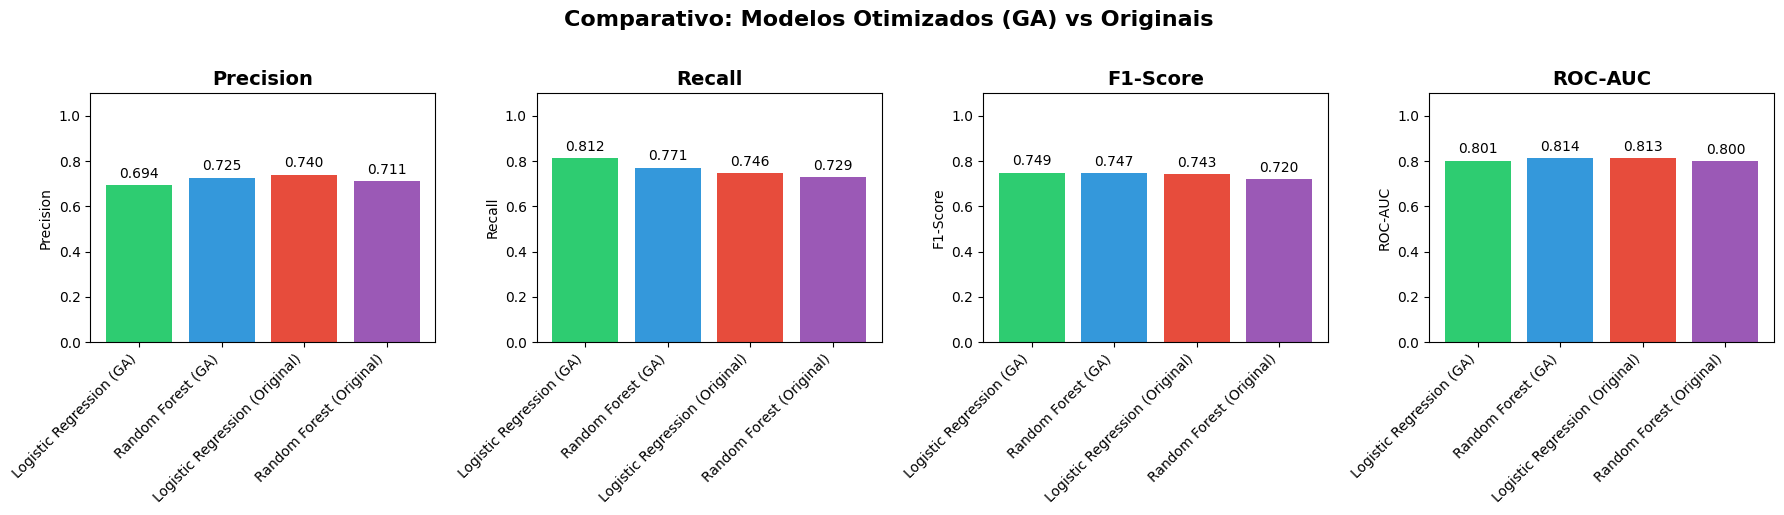


ANÁLISE DE MELHORIAS

Precision:
  Logistic Regression: 0.7397 → 0.6940 (-6.18%)
  Random Forest: 0.7114 → 0.7255 (+1.98%)

Recall:
  Logistic Regression: 0.7458 → 0.8125 (+8.94%)
  Random Forest: 0.7292 → 0.7708 (+5.71%)

F1-Score:
  Logistic Regression: 0.7427 → 0.7486 (+0.78%)
  Random Forest: 0.7202 → 0.7475 (+3.79%)

ROC-AUC:
  Logistic Regression: 0.8132 → 0.8013 (-1.46%)
  Random Forest: 0.7997 → 0.8136 (+1.73%)


In [36]:
# Visualização comparativa das métricas
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(results_df['Modelo'], results_df[metric], color=colors)
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')
    
    # Adicionar valores nas barras
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparativo: Modelos Otimizados (GA) vs Originais', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Destacar melhorias
print("\n" + "=" * 60)
print("ANÁLISE DE MELHORIAS")
print("=" * 60)

for metric in metrics:
    lr_orig = results_df[results_df['Modelo'].str.contains('Logistic.*Original')][metric].values[0]
    lr_ga = results_df[results_df['Modelo'].str.contains('Logistic.*GA')][metric].values[0]
    rf_orig = results_df[results_df['Modelo'].str.contains('Random.*Original')][metric].values[0]
    rf_ga = results_df[results_df['Modelo'].str.contains('Random.*GA')][metric].values[0]
    
    lr_delta = ((lr_ga - lr_orig) / lr_orig * 100) if lr_orig > 0 else 0
    rf_delta = ((rf_ga - rf_orig) / rf_orig * 100) if rf_orig > 0 else 0
    
    print(f"\n{metric}:")
    print(f"  Logistic Regression: {lr_orig:.4f} → {lr_ga:.4f} ({lr_delta:+.2f}%)")
    print(f"  Random Forest: {rf_orig:.4f} → {rf_ga:.4f} ({rf_delta:+.2f}%)")

In [37]:
# Selecionar e salvar o melhor modelo otimizado pelo F1-Score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Modelo']
print(f"Melhor modelo por F1-Score: {best_model_name}")

# Usar o modelo GA com melhor F1 para produtização
# ga_lr e ga_rf já foram atualizados para o melhor experimento GA
if 'Logistic' in best_model_name and 'GA' in best_model_name:
    best_ga_model = ga_lr if hasattr(ga_lr, 'best_estimator_') else ga_lr
elif 'Random' in best_model_name and 'GA' in best_model_name:
    best_ga_model = ga_rf if hasattr(ga_rf, 'best_estimator_') else ga_rf
elif 'Logistic' in best_model_name:
    best_ga_model = pipe_lr_orig
else:
    best_ga_model = pipe_rf_orig

# Se o modelo é um GASearchCV, extrair o best_estimator_
if hasattr(best_ga_model, 'best_estimator_'):
    best_ga_model = best_ga_model.best_estimator_

# Salvar modelo otimizado
import pickle
with open('pipe_model_ga_optimized.pkl', 'wb') as f:
    pickle.dump(best_ga_model, f)
    
print(f"Modelo otimizado salvo em: pipe_model_ga_optimized.pkl")

Melhor modelo por F1-Score: Logistic Regression (GA)
Modelo otimizado salvo em: pipe_model_ga_optimized.pkl


In [38]:
# Avaliar os modelos otimizados pelo GA na base balanceada
for name, model in [('LogisticRegression (GA)', ga_lr), ('RandomForest (GA)', ga_rf)]:
    y_pred_bal = model.predict(X_test_ga)
    y_prob_bal = model.predict_proba(X_test_ga)[:,1]
    
    print(f"===== {name} (base balanceada) =====")
    print(classification_report(y_test_ga, y_pred_bal))
    print('ROC AUC:', roc_auc_score(y_test_ga, y_prob_bal))
    precision, recall, _ = precision_recall_curve(y_test_ga, y_prob_bal)
    print('PR AUC:', auc(recall, precision))
    print('Confusion matrix:\n', confusion_matrix(y_test_ga, y_pred_bal))
    print()

# importância da permutação usando o melhor modelo GA
# best_ga_model já é um Pipeline (não GASearchCV)
X_test_trans = best_ga_model.named_steps['pre'].transform(X_test_ga)
r = permutation_importance(best_ga_model.named_steps['clf'], X_test_trans, y_test_ga, n_repeats=30, random_state=42, scoring='roc_auc')
feat_names = best_ga_model.named_steps['pre'].get_feature_names_out()

# criar DataFrame de importâncias
imp_df = pd.DataFrame({'feature': feat_names, 'importance': r.importances_mean, 'std': r.importances_std})
imp_df = imp_df.sort_values('importance', ascending=False)

print(f'\nAs 10 principais características por importância de permutação (Melhor modelo GA: {best_model_name}):')
print(imp_df.head(10))

===== LogisticRegression (GA) (base balanceada) =====
              precision    recall  f1-score   support

           0       0.78      0.64      0.70       241
           1       0.69      0.81      0.75       240

    accuracy                           0.73       481
   macro avg       0.73      0.73      0.73       481
weighted avg       0.73      0.73      0.73       481

ROC AUC: 0.8013312586445366
PR AUC: 0.7735931184065906
Confusion matrix:
 [[155  86]
 [ 45 195]]

===== RandomForest (GA) (base balanceada) =====
              precision    recall  f1-score   support

           0       0.76      0.71      0.73       241
           1       0.73      0.77      0.75       240

    accuracy                           0.74       481
   macro avg       0.74      0.74      0.74       481
weighted avg       0.74      0.74      0.74       481

ROC AUC: 0.8135546334716458
PR AUC: 0.7767149241930358
Confusion matrix:
 [[171  70]
 [ 55 185]]


As 10 principais características por importânci

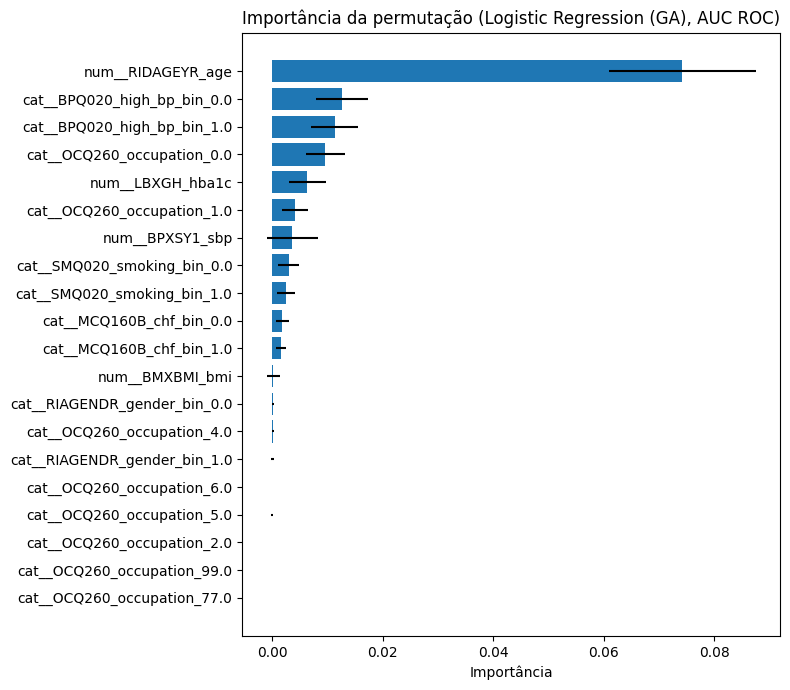

In [39]:
# plote as principais permutações de importância (selecione as 20 principais para melhor visualização).
top_k = min(20, len(imp_df))

# ordene o gráfico de barras horizontais em ordem crescente (com os elementos mais importantes no topo).
top = imp_df.head(top_k).sort_values('importance', ascending=True)
plt.figure(figsize=(8, max(4, 0.35*top_k)))
plt.barh(top['feature'], top['importance'], xerr=top['std'], color='C0')
plt.xlabel('Importância')
plt.title(f'Importância da permutação ({best_model_name}, AUC ROC)')
plt.tight_layout()
plt.show()

RANKING COMPLETO — TODOS OS MODELOS (por média de Recall + F1)
                                       Modelo    Recall  F1-Score  Média (Recall+F1)/2 Δ Recall vs anterior Δ F1 vs anterior Δ Média vs anterior
Rank                                                                                                                                            
1             LR — Exp1 (sklearn-genetic-opt)  0.812500  0.748560             0.780530                 None             None                None
2     LR — Exp2 (GA Manual, pop=30, mut=0.05)  0.800000  0.745631             0.772816               -1.54%           -0.39%              -0.99%
3     LR — Exp3 (GA Manual, pop=10, mut=0.25)  0.800000  0.745631             0.772816               +0.00%           +0.00%              +0.00%
4     RF — Exp3 (GA Manual, pop=10, mut=0.25)  0.770833  0.747475             0.759154               -3.65%           +0.25%              -1.77%
5             RF — Exp1 (sklearn-genetic-opt)  0.758333  0.739837  

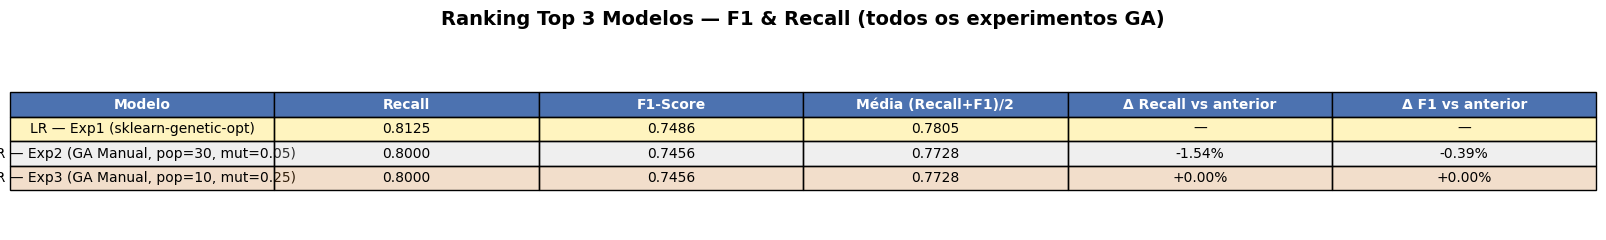

In [40]:
# Ranqueamento Top 3 por F1 e Recall (classe 1 = AVC) — inclui todos os experimentos GA
from sklearn.metrics import recall_score, f1_score

ranking_data = []

# Todos os modelos: 3 experimentos GA × 2 modelos + 2 originais = 8 modelos
models_to_rank = [
    ('LR — Exp1 (sklearn-genetic-opt)', ga_experiments['Logistic Regression']['Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)']),
    ('LR — Exp2 (GA Manual, pop=30, mut=0.05)', ga_experiments['Logistic Regression']['Exp2 (GA Manual, pop=30, mut=0.05)']),
    ('LR — Exp3 (GA Manual, pop=10, mut=0.25)', ga_experiments['Logistic Regression']['Exp3 (GA Manual, pop=10, mut=0.25)']),
    ('RF — Exp1 (sklearn-genetic-opt)', ga_experiments['Random Forest']['Exp1 (sklearn-genetic-opt, pop=15, mut=0.10)']),
    ('RF — Exp2 (GA Manual, pop=30, mut=0.05)', ga_experiments['Random Forest']['Exp2 (GA Manual, pop=30, mut=0.05)']),
    ('RF — Exp3 (GA Manual, pop=10, mut=0.25)', ga_experiments['Random Forest']['Exp3 (GA Manual, pop=10, mut=0.25)']),
    ('LR — Original (sem GA)', pipe_lr_orig),
    ('RF — Original (sem GA)', pipe_rf_orig),
]

for name, model in models_to_rank:
    y_pred = model.predict(X_test_ga)
    rec = recall_score(y_test_ga, y_pred)
    f1 = f1_score(y_test_ga, y_pred)
    ranking_data.append({'Modelo': name, 'Recall': rec, 'F1-Score': f1})

rank_df = pd.DataFrame(ranking_data)
rank_df['Média (Recall+F1)/2'] = (rank_df['Recall'] + rank_df['F1-Score']) / 2
rank_df = rank_df.sort_values('Média (Recall+F1)/2', ascending=False).reset_index(drop=True)
rank_df.index = rank_df.index + 1  # ranking começa em 1
rank_df.index.name = 'Rank'

# Calcular % de melhoria em relação ao modelo imediatamente anterior no ranking
recall_pct = [None]
f1_pct = [None]
media_pct = [None]
for i in range(1, len(rank_df)):
    prev_recall = rank_df.iloc[i-1]['Recall']
    prev_f1 = rank_df.iloc[i-1]['F1-Score']
    prev_media = rank_df.iloc[i-1]['Média (Recall+F1)/2']
    
    curr_recall = rank_df.iloc[i]['Recall']
    curr_f1 = rank_df.iloc[i]['F1-Score']
    curr_media = rank_df.iloc[i]['Média (Recall+F1)/2']
    
    recall_pct.append(f"{((curr_recall - prev_recall) / prev_recall * 100):+.2f}%" if prev_recall > 0 else "—")
    f1_pct.append(f"{((curr_f1 - prev_f1) / prev_f1 * 100):+.2f}%" if prev_f1 > 0 else "—")
    media_pct.append(f"{((curr_media - prev_media) / prev_media * 100):+.2f}%" if prev_media > 0 else "—")

rank_df['Δ Recall vs anterior'] = recall_pct
rank_df['Δ F1 vs anterior'] = f1_pct
rank_df['Δ Média vs anterior'] = media_pct

# Exibir ranking completo
print("=" * 90)
print("RANKING COMPLETO — TODOS OS MODELOS (por média de Recall + F1)")
print("=" * 90)
print(rank_df.to_string())
print()

# Exibir Top 3
top3 = rank_df.head(3)
print("=" * 90)
print("RANKING TOP 3 MODELOS")
print("=" * 90)
print(top3.to_string())

# Visualização em tabela estilizada (Top 3)
fig, ax = plt.subplots(figsize=(16, 2.5))
ax.axis('off')
cols = ['Modelo', 'Recall', 'F1-Score', 'Média (Recall+F1)/2', 'Δ Recall vs anterior', 'Δ F1 vs anterior']
cell_text = []
for _, row in top3.iterrows():
    cell_text.append([
        row['Modelo'],
        f"{row['Recall']:.4f}",
        f"{row['F1-Score']:.4f}",
        f"{row['Média (Recall+F1)/2']:.4f}",
        row['Δ Recall vs anterior'] if row['Δ Recall vs anterior'] else '—',
        row['Δ F1 vs anterior'] if row['Δ F1 vs anterior'] else '—',
    ])

table = ax.table(cellText=cell_text, colLabels=cols, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

# Colorir cabeçalho
for j in range(len(cols)):
    table[0, j].set_facecolor('#4c72b0')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Colorir medalhas (1º, 2º, 3º)
medal_colors = ['#FFD700', '#C0C0C0', '#CD7F32']
for i in range(len(cell_text)):
    for j in range(len(cols)):
        table[i+1, j].set_facecolor(medal_colors[i] + '40')

plt.title('Ranking Top 3 Modelos — F1 & Recall (todos os experimentos GA)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Produtização

In [41]:
import pickle

# Salvar o melhor modelo otimizado pelo GA
with open('pipe_model.pkl', 'wb') as f:
    pickle.dump(best_ga_model, f)

print(f"Modelo salvo: {best_model_name}")

# Escolha dois registros aleatórios da base de teste (um com AVC e outro sem AVC) para teste do modelo salvo
test_samples = pd.concat([
    X_test_ga[y_test_ga == 1].sample(n=1, random_state=42),
    X_test_ga[y_test_ga == 0].sample(n=1, random_state=42)
])

# Adicionar coluna indicando se é stroke ou não
test_samples['MCQ160F_stroke_bin'] = y_test_ga.loc[test_samples.index]
test_samples['stroke_label'] = test_samples['MCQ160F_stroke_bin'].map({1: 'Stroke (Sim)', 0: 'No Stroke (Não)'})

test_samples.head(2)

Modelo salvo: Logistic Regression (GA)


,RIDAGEYR_age,BPXSY1_sbp,LBXGH_hba1c,BMXBMI_bmi,RIAGENDR_gender_bin,DMDMARTL_married_bin,BPQ020_high_bp_bin,MCQ160B_chf_bin,OCQ260_occupation,SMQ020_smoking_bin,MCQ160F_stroke_bin,stroke_label
151,53.0,118.0,5.9,27.8,0,1,1,1,0.0,1,1,Stroke (Sim)
2252,24.0,124.0,5.6,40.8,0,0,0,0,1.0,0,0,No Stroke (Não)


In [42]:
import json

# converte os registros em lista de dicts (orientação records)
test_samples_json = test_samples.reset_index(drop=True).to_dict(orient='records')

# mapeamento de nomes originais para amigáveis
rename_map = {
    'RIDAGEYR_age': 'age',
    'BPXSY1_sbp': 'sbp',
    'LBXGH_hba1c': 'hba1c',
    'BMXBMI_bmi': 'bmi',
    'RIAGENDR_gender_bin': 'gender',
    'DMDMARTL_married_bin': 'married',
    'BPQ020_high_bp_bin': 'high_bp',
    'MCQ160B_chf_bin': 'chf',
    'OCQ260_occupation': 'occupation',
    'SMQ020_smoking_bin': 'smoking'
}

# renomear as chaves em cada dicionário da lista
test_samples_json_renamed = []
for sample in test_samples_json:
    renamed_sample = {rename_map.get(k, k): v for k, v in sample.items() if k not in ['MCQ160F_stroke_bin', 'stroke_label']}
    test_samples_json_renamed.append(renamed_sample)

# converter para string JSON formatada
test_samples_json_str = json.dumps(test_samples_json_renamed, ensure_ascii=False, indent=2)

# exibe o JSON
print(test_samples_json_str)

[
  {
    "age": 53.0,
    "sbp": 118.0,
    "hba1c": 5.9,
    "bmi": 27.8,
    "gender": 0,
    "married": 1,
    "high_bp": 1,
    "chf": 1,
    "occupation": 0.0,
    "smoking": 1
  },
  {
    "age": 24.0,
    "sbp": 124.0,
    "hba1c": 5.6,
    "bmi": 40.8,
    "gender": 0,
    "married": 0,
    "high_bp": 0,
    "chf": 0,
    "occupation": 1.0,
    "smoking": 0
  }
]
